# Reintegration Progress Pipeline
## Lighthouse Sanctuary — Scoring Pipeline (CRISP-DM Framework)

This notebook builds a complete **end-to-end Reintegration Progress Scoring Pipeline**
that computes a **Reintegration Progress Score (0–100)** for each resident — giving
social workers a data-driven snapshot of how well each girl is progressing toward
safe reintegration into family life or independent living.

Unlike a classifier that learns from labeled examples, this pipeline uses a
**domain-knowledge-driven composite score**: a weighted combination of six life
domains, each measured from real clinical data.

---

### The 6 CRISP-DM Phases Covered Here:

| Phase | What We Do |
|---|---|
| **1. Business Understanding** | What is reintegration progress? What does a score mean in the real world? |
| **2. Data Understanding** | Explore the seven source tables — distributions, patterns, data quality |
| **3. Data Preparation** | Aggregate per-resident features from each domain, encode ordinal fields |
| **4. Scoring Model** | Compute six domain sub-scores and one weighted composite score |
| **5. Trend Analysis** | Track score changes over time; flag residents who are stalling or regressing |
| **6. Deployment** | Export results, save config, and provide a reusable `score_resident()` function |

---

### Data Sources (7 Tables):

| Table | Domain |
|---|---|
| `process_recordings` | Psychological (counseling sessions) |
| `home_visitations` | Family Environment |
| `education_records` | Education |
| `health_wellbeing_records` | Physical Wellbeing |
| `intervention_plans` | Intervention Progress |
| `incident_reports` | Behavioral Stability |
| `residents` | Context + risk trajectory adjustment |

---

### Important — What This Pipeline Does NOT Do:
This pipeline does **not** recommend or modify the `reintegration_type` field
(Family Reunification, Foster Care, Adoption, etc.). That decision is made entirely
by staff. The score supports — it does not replace — human judgment.

In [ ]:
# =============================================================================
# PIPELINE CONFIGURATION
# To run this pipeline on a different dataset, only change the values in this
# cell. Everything below adapts automatically.
# =============================================================================

import warnings
warnings.filterwarnings("ignore")

import os
os.makedirs("models", exist_ok=True)

# --- File paths (relative to this notebook's location) ---
RESIDENTS_PATH     = "../lighthouse_csv_v7/residents.csv"
PROCESS_PATH       = "../lighthouse_csv_v7/process_recordings.csv"
VISITATIONS_PATH   = "../lighthouse_csv_v7/home_visitations.csv"
INCIDENTS_PATH     = "../lighthouse_csv_v7/incident_reports.csv"
EDUCATION_PATH     = "../lighthouse_csv_v7/education_records.csv"
HEALTH_PATH        = "../lighthouse_csv_v7/health_wellbeing_records.csv"
INTERVENTIONS_PATH = "../lighthouse_csv_v7/intervention_plans.csv"

# --- Consistent random seed: keeps results identical every run ---
RANDOM_STATE = 27

# --- Domain weights: how much each life area counts toward the composite score ---
# All six values must add up to exactly 1.0 (100%)
DOMAIN_WEIGHTS = {
    "psychological":      0.25,   # Counseling progress and emotional health
    "family_environment": 0.25,   # Family readiness and home safety
    "education":          0.20,   # Academic or vocational progress
    "physical_wellbeing": 0.15,   # Health, nutrition, and energy
    "intervention":       0.10,   # Goal-setting and plan completion
    "behavioral":         0.05,   # Incident stability (fewer incidents = more stable)
}

# --- Trend detection thresholds ---
STALLING_MONTHS = 2     # Flag as 'Stalling' if score doesn't improve for N months in a row
REGRESS_DELTA   = -5.0  # Flag as 'Regressing' if score drops this many points in one month

# --- Output file paths ---
SCORE_SAVE_PATH  = "models/reintegration_scores.csv"
FLAG_SAVE_PATH   = "models/reintegration_flags.csv"
CONFIG_SAVE_PATH = "models/reintegration_score_config.joblib"

print("Pipeline configuration loaded.")
print(f"  Domains and weights:")
for domain, weight in DOMAIN_WEIGHTS.items():
    print(f"    {domain:<22}: {weight*100:.0f}%")
print(f"  Stalling threshold  : {STALLING_MONTHS} months flat")
print(f"  Regression threshold: {REGRESS_DELTA} points/month")
print(f"  Total weight check  : {sum(DOMAIN_WEIGHTS.values())*100:.0f}% (must be 100%)")

Pipeline configuration loaded.
  Domains and weights:
    psychological         : 25%
    family_environment    : 25%
    education             : 20%
    physical_wellbeing    : 15%
    intervention          : 10%
    behavioral            : 5%
  Stalling threshold  : 2 months flat
  Regression threshold: -5.0 points/month
  Total weight check  : 100% (must be 100%)


# Phase 1: Business Understanding

## Who Are We Building This For?

**Lighthouse Sanctuary** is a US-based nonprofit (501(c)(3)) that operates safe homes
for girls who are survivors of sexual abuse and trafficking in the Philippines. A new
organization modeled after Lighthouse Sanctuary is building its technology stack.
This pipeline is one of three ML pipelines powering that system.

---

## The Problem

With limited staff managing multiple safehouses, social workers cannot always give
equal attention to every resident. Reintegration — the process of safely returning a
girl to family life or independent living — requires steady progress across multiple
areas of life:

- Is she emotionally healing? Are counseling sessions going well?
- Is her family ready and safe to receive her?
- Is she making academic or vocational progress?
- Is her physical health stable?
- Are her individual goals being met?
- Is she behaviorally stable (no incidents, self-harm, or runaway attempts)?

Currently these questions are answered through periodic case reviews. The risk is that
**a resident can slip through the cracks between reviews** — stalling or regressing
without triggering a timely intervention.

---

## Our Solution

We build a **composite progress score (0–100)** for each resident, made up of six
domain sub-scores:

| Score Range | Interpretation |
|---|---|
| **75–100** | Strong progress — resident is approaching reintegration readiness |
| **50–74** | Moderate progress — some areas need attention |
| **25–49** | Limited progress — significant gaps in one or more domains |
| **0–24** | Minimal progress — intensive intervention needed |

The score is updated monthly as new data comes in. Staff can see **which domain is
dragging the score down** and prioritize support accordingly.

### What a Score Change Means:
- **Progressing**: Score improved this month — current interventions are working.
- **Stable**: Score is flat — resident is maintaining but not advancing.
- **Stalling**: Score has been flat for 2+ months — time to review the care plan.
- **Regressing**: Score dropped significantly — urgent attention needed.

---

## Success Criteria

This pipeline succeeds if:
1. Every active resident has a meaningful, data-backed progress score
2. Staff can see which specific domain is limiting a resident's progress
3. Residents who are stalling or regressing are automatically flagged for review
4. The score trends upward over time for residents who are successfully reintegrating

---

## Key Constraints and Ethical Notes

1. **Score as a tool, not a verdict**: The composite score is one input to a social
   worker's judgment. It highlights patterns — it does not make decisions.
2. **Sparse data**: Some residents (especially new admissions) will have fewer records.
   The scoring formula handles this by weighting only available domains.
3. **reintegration_type is staff-only**: This pipeline never suggests, overrides, or
   influences the reintegration type (Family Reunification, Foster Care, etc.).
   That field is entirely the domain of trained social workers and legal authorities.

# Phase 2: Data Understanding

Before building any scoring model, we explore the data to understand:
- What seven tables we are working with and how many records each has
- Where residents currently stand in their reintegration journeys
- How much data each resident has in each domain
- The distributions of the key fields that will drive the scores

Think of this as reading every resident's full case file before designing the
scoring rubric — the more we understand the data, the better the scores will
reflect real-world progress.

In [ ]:
# =============================================================================
# PHASE 2, STEP 1: Import libraries and load all seven datasets
# =============================================================================

# numpy — math and array operations (the backbone of numerical Python)
import numpy as np

# pandas — load and manipulate tabular data (like a very powerful spreadsheet)
import pandas as pd

# matplotlib and seaborn — for creating charts and visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean, consistent chart style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"]     = 100

# --- Load all seven CSVs ---
df_residents     = pd.read_csv(RESIDENTS_PATH)
df_process       = pd.read_csv(PROCESS_PATH)
df_visitations   = pd.read_csv(VISITATIONS_PATH)
df_incidents     = pd.read_csv(INCIDENTS_PATH)
df_education     = pd.read_csv(EDUCATION_PATH)
df_health        = pd.read_csv(HEALTH_PATH)
df_interventions = pd.read_csv(INTERVENTIONS_PATH)

# --- Parse all date columns so Python knows they are dates, not plain text ---
df_residents["date_of_admission"]  = pd.to_datetime(df_residents["date_of_admission"])
df_process["session_date"]         = pd.to_datetime(df_process["session_date"])
df_visitations["visit_date"]       = pd.to_datetime(df_visitations["visit_date"])
df_incidents["incident_date"]      = pd.to_datetime(df_incidents["incident_date"])
df_education["record_date"]        = pd.to_datetime(df_education["record_date"])
df_health["record_date"]           = pd.to_datetime(df_health["record_date"])
df_interventions["created_at"]     = pd.to_datetime(df_interventions["created_at"])
df_interventions["updated_at"]     = pd.to_datetime(df_interventions["updated_at"])

# --- Print a summary of how much data we have in each table ---
tables = {
    "residents":             df_residents,
    "process_recordings":    df_process,
    "home_visitations":      df_visitations,
    "incident_reports":      df_incidents,
    "education_records":     df_education,
    "health_wellbeing":      df_health,
    "intervention_plans":    df_interventions,
}

print("All datasets loaded successfully!\n")
print(f"{'Table':<28} {'Rows':>6}  {'Columns':>8}  {'Unique Residents':>18}")
print("-" * 68)
for name, df in tables.items():
    if name == "residents":
        unique_res = "(primary table)"
    else:
        unique_res = str(df["resident_id"].nunique())
    print(f"{name:<28} {df.shape[0]:>6}  {df.shape[1]:>8}  {unique_res:>18}")

All datasets loaded successfully!

Table                          Rows   Columns    Unique Residents
--------------------------------------------------------------------
residents                        60        49     (primary table)
process_recordings             2819        15                  60
home_visitations               1337        14                  58
incident_reports                100        12                  44
education_records               534        10                  60
health_wellbeing                534        14                  60
intervention_plans              180        11                  60


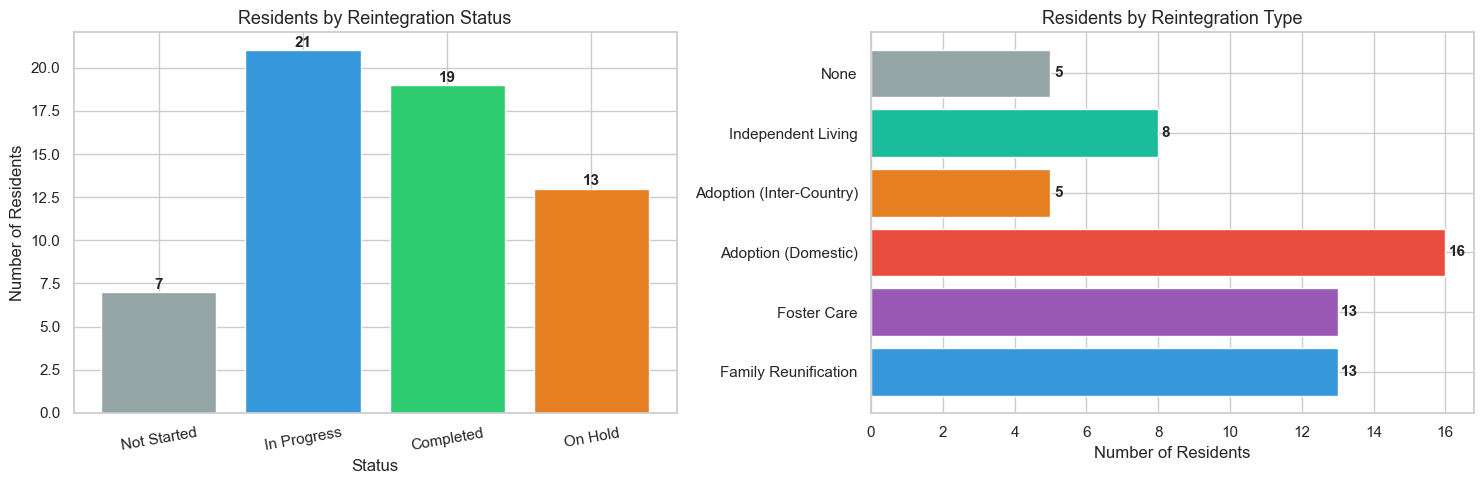

Reintegration Status Breakdown:
  Not Started         :   7 residents (12%)
  In Progress         :  21 residents (35%)
  Completed           :  19 residents (32%)
  On Hold             :  13 residents (22%)


In [ ]:
# =============================================================================
# PHASE 2, STEP 2: Where are residents in their reintegration journeys?
#
# WHY WE DO THIS: The 'reintegration_status' and 'reintegration_type' fields
# tell us the current official standing of each case. Understanding this
# distribution helps us verify that our pipeline will produce meaningful scores
# across the full range of residents — not just those far along in the process.
# =============================================================================

# Fill any missing values with sensible defaults
df_residents["reintegration_status"] = df_residents["reintegration_status"].fillna("Not Started")
df_residents["reintegration_type"]   = df_residents["reintegration_type"].fillna("None")

status_order = ["Not Started", "In Progress", "Completed", "On Hold"]
type_order   = ["Family Reunification", "Foster Care", "Adoption (Domestic)",
                "Adoption (Inter-Country)", "Independent Living", "None"]

status_counts = df_residents["reintegration_status"].value_counts().reindex(status_order).fillna(0)
type_counts   = df_residents["reintegration_type"].value_counts().reindex(type_order).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: Reintegration status distribution
status_colors = ["#95a5a6", "#3498db", "#2ecc71", "#e67e22"]
axes[0].bar(status_counts.index, status_counts.values, color=status_colors)
axes[0].set_title("Residents by Reintegration Status", fontsize=13)
axes[0].set_xlabel("Status")
axes[0].set_ylabel("Number of Residents")
for i, v in enumerate(status_counts.values):
    axes[0].text(i, v + 0.2, str(int(v)), ha="center", fontsize=11, fontweight="bold")
axes[0].tick_params(axis="x", rotation=10)

# Right: Reintegration type distribution
type_colors = ["#3498db", "#9b59b6", "#e74c3c", "#e67e22", "#1abc9c", "#95a5a6"]
axes[1].barh(type_counts.index, type_counts.values, color=type_colors)
axes[1].set_title("Residents by Reintegration Type", fontsize=13)
axes[1].set_xlabel("Number of Residents")
for i, v in enumerate(type_counts.values):
    axes[1].text(v + 0.1, i, str(int(v)), va="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

print("Reintegration Status Breakdown:")
for status, count in status_counts.items():
    pct = count / len(df_residents) * 100
    print(f"  {status:<20}: {int(count):>3} residents ({pct:.0f}%)")

Average records per resident across all domains:
  Counseling sessions : 47.0  (range: 11–118)
  Home visits         : 22.3  (range: 0–64)
  Education records   : 8.9  (range: 6–12)
  Health records      : 8.9  (range: 6–12)
  Intervention plans  : 3.0  (range: 3–3)
  Incident reports    : 1.7  (range: 0–5)

Residents with NO records in each domain (sparse data warning):
  No sessions       : 0
  No visits         : 2
  No edu records    : 0
  No health records : 0
  No plans          : 0
  No incidents      : 16 (zero incidents is a GOOD sign)


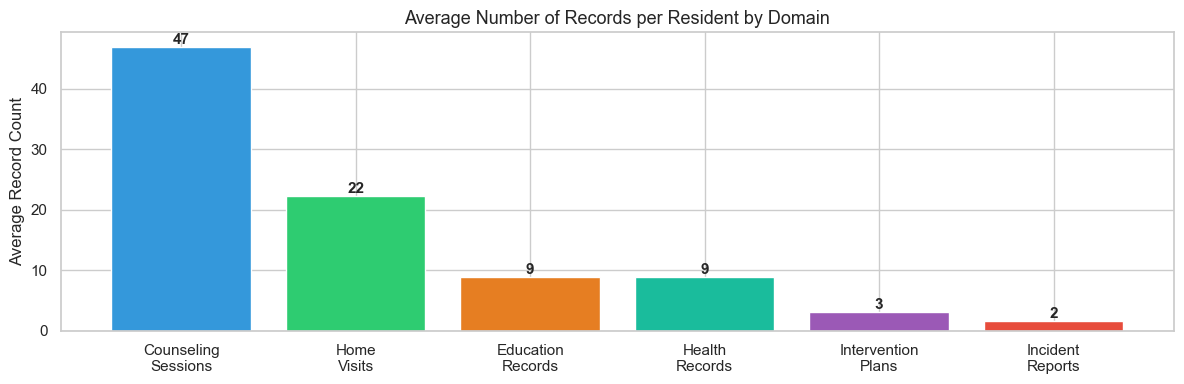

In [ ]:
# =============================================================================
# PHASE 2, STEP 3: How much data do we have per resident?
#
# WHY WE DO THIS: Not every resident will have the same amount of data.
# A resident who arrived last month will have far fewer counseling sessions
# than one who has been in the program for two years. We need to understand
# this BEFORE building scores — residents with very little data need special
# handling in Phase 3 to avoid unfairly low scores.
# =============================================================================

# Count how many records each resident has in each supporting table
rec = pd.DataFrame({"resident_id": df_residents["resident_id"]})
rec["sessions"]    = rec["resident_id"].map(df_process.groupby("resident_id").size()).fillna(0).astype(int)
rec["visits"]      = rec["resident_id"].map(df_visitations.groupby("resident_id").size()).fillna(0).astype(int)
rec["edu_records"] = rec["resident_id"].map(df_education.groupby("resident_id").size()).fillna(0).astype(int)
rec["health_recs"] = rec["resident_id"].map(df_health.groupby("resident_id").size()).fillna(0).astype(int)
rec["plans"]       = rec["resident_id"].map(df_interventions.groupby("resident_id").size()).fillna(0).astype(int)
rec["incidents"]   = rec["resident_id"].map(df_incidents.groupby("resident_id").size()).fillna(0).astype(int)

print("Average records per resident across all domains:")
print(f"  Counseling sessions : {rec['sessions'].mean():.1f}  (range: {rec['sessions'].min()}–{rec['sessions'].max()})")
print(f"  Home visits         : {rec['visits'].mean():.1f}  (range: {rec['visits'].min()}–{rec['visits'].max()})")
print(f"  Education records   : {rec['edu_records'].mean():.1f}  (range: {rec['edu_records'].min()}–{rec['edu_records'].max()})")
print(f"  Health records      : {rec['health_recs'].mean():.1f}  (range: {rec['health_recs'].min()}–{rec['health_recs'].max()})")
print(f"  Intervention plans  : {rec['plans'].mean():.1f}  (range: {rec['plans'].min()}–{rec['plans'].max()})")
print(f"  Incident reports    : {rec['incidents'].mean():.1f}  (range: {rec['incidents'].min()}–{rec['incidents'].max()})")
print()
print("Residents with NO records in each domain (sparse data warning):")
print(f"  No sessions       : {(rec['sessions'] == 0).sum()}")
print(f"  No visits         : {(rec['visits'] == 0).sum()}")
print(f"  No edu records    : {(rec['edu_records'] == 0).sum()}")
print(f"  No health records : {(rec['health_recs'] == 0).sum()}")
print(f"  No plans          : {(rec['plans'] == 0).sum()}")
print(f"  No incidents      : {(rec['incidents'] == 0).sum()} (zero incidents is a GOOD sign)")

# Bar chart: average record counts across domains
domain_labels = ["Counseling\nSessions", "Home\nVisits", "Education\nRecords",
                 "Health\nRecords", "Intervention\nPlans", "Incident\nReports"]
domain_means  = [rec[c].mean() for c in ["sessions", "visits", "edu_records", "health_recs", "plans", "incidents"]]
domain_colors = ["#3498db", "#2ecc71", "#e67e22", "#1abc9c", "#9b59b6", "#e74c3c"]

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(domain_labels, domain_means, color=domain_colors)
ax.set_title("Average Number of Records per Resident by Domain", fontsize=13)
ax.set_ylabel("Average Record Count")
for bar, mean in zip(bars, domain_means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"{mean:.0f}", ha="center", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

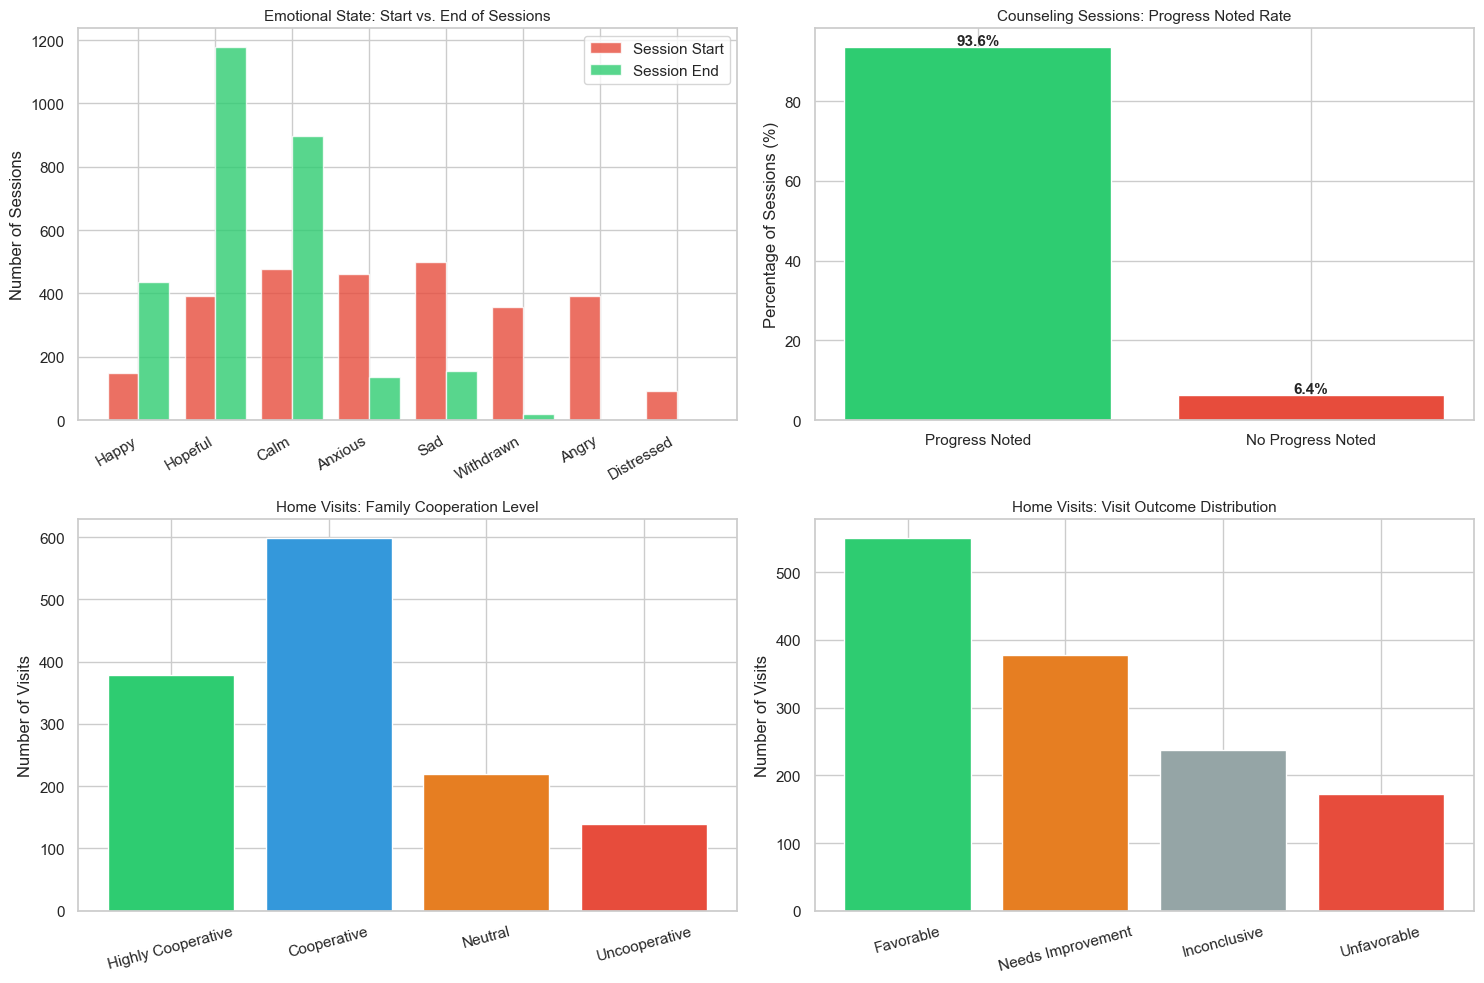

Key Signal Summary:
  Sessions where progress was noted      : 93.6%
  Sessions where concerns were flagged   : 24.0%
  Home visits with a Favorable outcome   : 41.2%
  Home visits with safety concerns noted : 27.2%


In [ ]:
# =============================================================================
# PHASE 2, STEP 4: Explore psychological and family environment data
#
# WHY WE DO THIS: We want to confirm that the data has real, meaningful
# variation across residents. A scoring model only works if the underlying
# data actually captures differences between residents who are doing well
# vs. those who are struggling.
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# --- Counseling sessions: emotional state at start vs. end ---
emo_order = ["Happy", "Hopeful", "Calm", "Anxious", "Sad", "Withdrawn", "Angry", "Distressed"]

start_counts = df_process["emotional_state_observed"].value_counts().reindex(emo_order).fillna(0)
end_counts   = df_process["emotional_state_end"].value_counts().reindex(emo_order).fillna(0)

x = range(len(emo_order))
width = 0.4
axes[0, 0].bar([i - width/2 for i in x], start_counts.values, width=width, label="Session Start", color="#e74c3c", alpha=0.8)
axes[0, 0].bar([i + width/2 for i in x], end_counts.values,   width=width, label="Session End",   color="#2ecc71", alpha=0.8)
axes[0, 0].set_xticks(list(x))
axes[0, 0].set_xticklabels(emo_order, rotation=30, ha="right")
axes[0, 0].set_title("Emotional State: Start vs. End of Sessions", fontsize=11)
axes[0, 0].set_ylabel("Number of Sessions")
axes[0, 0].legend()

# --- Counseling sessions: progress noted rate by session ---
progress_rate = df_process["progress_noted"].value_counts(normalize=True) * 100
axes[0, 1].bar(["Progress Noted", "No Progress Noted"],
               [progress_rate.get(True, 0), progress_rate.get(False, 0)],
               color=["#2ecc71", "#e74c3c"])
axes[0, 1].set_title("Counseling Sessions: Progress Noted Rate", fontsize=11)
axes[0, 1].set_ylabel("Percentage of Sessions (%)")
for i, v in enumerate([progress_rate.get(True, 0), progress_rate.get(False, 0)]):
    axes[0, 1].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=11, fontweight="bold")

# --- Home visits: family cooperation level ---
coop_order  = ["Highly Cooperative", "Cooperative", "Neutral", "Uncooperative"]
coop_counts = df_visitations["family_cooperation_level"].value_counts().reindex(coop_order).fillna(0)
axes[1, 0].bar(coop_counts.index, coop_counts.values,
               color=["#2ecc71", "#3498db", "#e67e22", "#e74c3c"])
axes[1, 0].set_title("Home Visits: Family Cooperation Level", fontsize=11)
axes[1, 0].set_ylabel("Number of Visits")
axes[1, 0].tick_params(axis="x", rotation=15)

# --- Home visits: visit outcome distribution ---
outcome_order  = ["Favorable", "Needs Improvement", "Inconclusive", "Unfavorable"]
outcome_counts = df_visitations["visit_outcome"].value_counts().reindex(outcome_order).fillna(0)
axes[1, 1].bar(outcome_counts.index, outcome_counts.values,
               color=["#2ecc71", "#e67e22", "#95a5a6", "#e74c3c"])
axes[1, 1].set_title("Home Visits: Visit Outcome Distribution", fontsize=11)
axes[1, 1].set_ylabel("Number of Visits")
axes[1, 1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

# Print summary percentages
pct_progress = df_process["progress_noted"].mean() * 100
pct_concerns = df_process["concerns_flagged"].mean() * 100
pct_favorable= (df_visitations["visit_outcome"] == "Favorable").mean() * 100
pct_safety   = df_visitations["safety_concerns_noted"].mean() * 100

print("Key Signal Summary:")
print(f"  Sessions where progress was noted      : {pct_progress:.1f}%")
print(f"  Sessions where concerns were flagged   : {pct_concerns:.1f}%")
print(f"  Home visits with a Favorable outcome   : {pct_favorable:.1f}%")
print(f"  Home visits with safety concerns noted : {pct_safety:.1f}%")

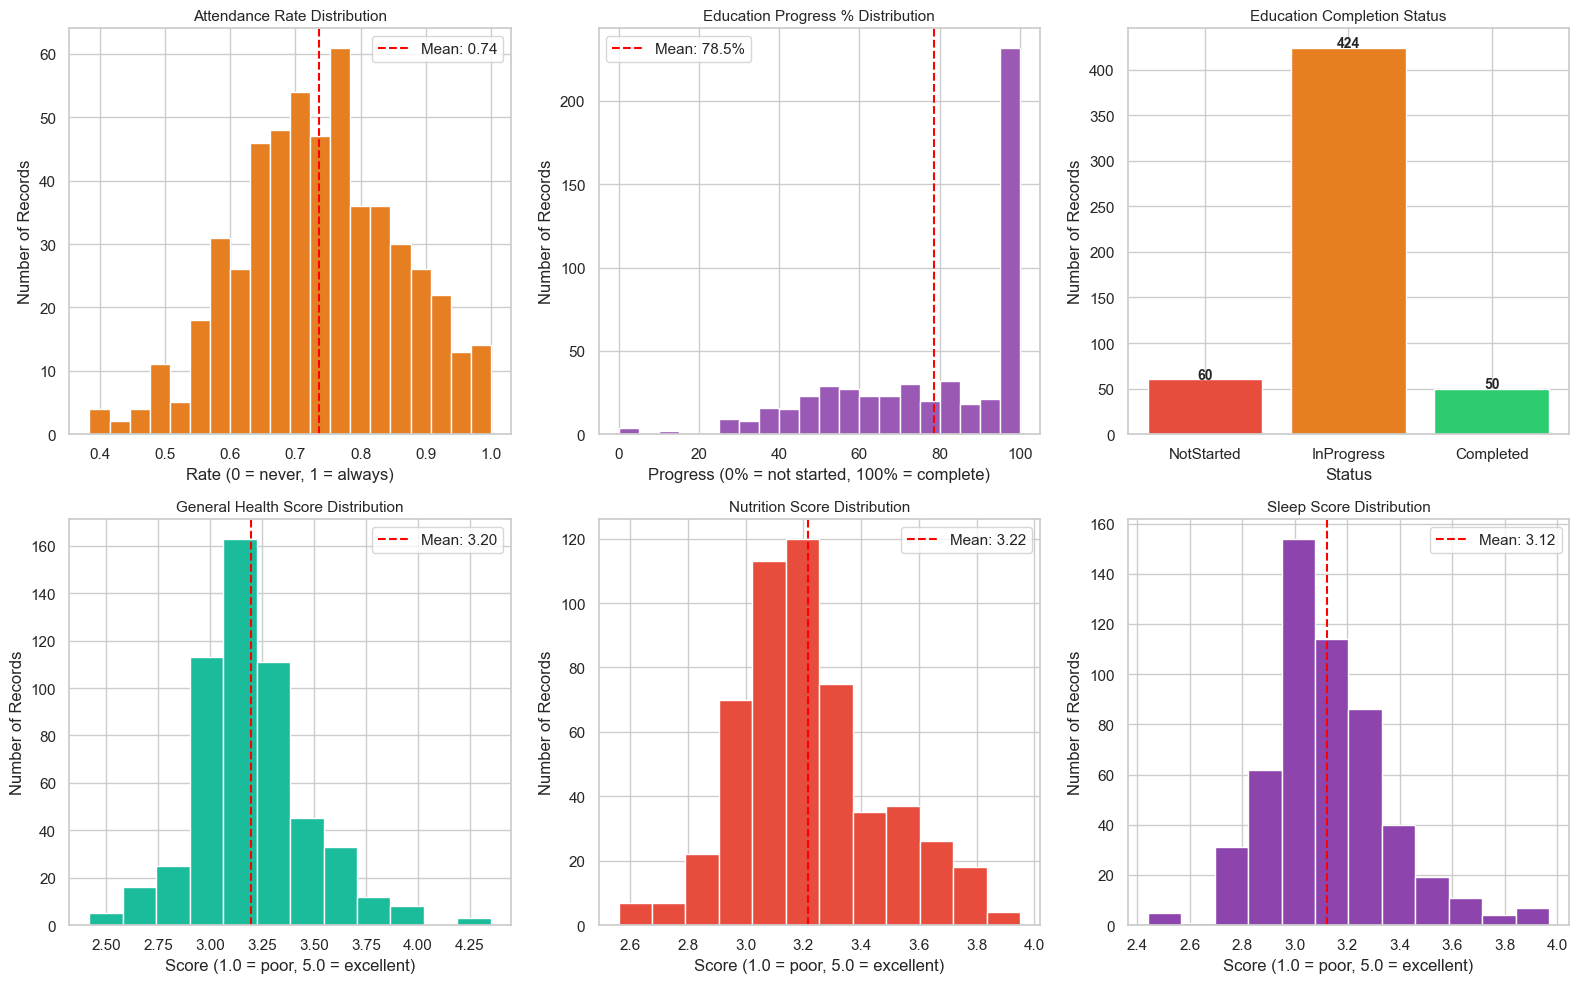

Education — Key Statistics:
  Avg attendance rate   : 0.74
  Avg progress percent  : 78.5%
  Completion rate       : 9.4% of records marked Completed

Health & Wellbeing — Key Statistics:
  Avg general_health_score     : 3.20 / 5.0
  Avg nutrition_score          : 3.22 / 5.0
  Avg sleep_quality_score      : 3.12 / 5.0
  Avg energy_level_score       : 2.98 / 5.0


In [ ]:
# =============================================================================
# PHASE 2, STEP 5: Explore education and physical health data
#
# Education and health records are collected monthly — one record per resident
# per month. This gives us the richest time-series data in the dataset.
# NOTE: completion_status (NotStarted/InProgress/Completed) is encoded 0–1 in scoring.
# =============================================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Row 1: Education fields
axes[0, 0].hist(df_education["attendance_rate"].dropna(), bins=20, color="#e67e22", edgecolor="white")
axes[0, 0].set_title("Attendance Rate Distribution", fontsize=11)
axes[0, 0].set_xlabel("Rate (0 = never, 1 = always)")
axes[0, 0].set_ylabel("Number of Records")
axes[0, 0].axvline(df_education["attendance_rate"].mean(), color="red", linestyle="--",
                   label=f"Mean: {df_education['attendance_rate'].mean():.2f}")
axes[0, 0].legend()

axes[0, 1].hist(df_education["progress_percent"].dropna(), bins=20, color="#9b59b6", edgecolor="white")
axes[0, 1].set_title("Education Progress % Distribution", fontsize=11)
axes[0, 1].set_xlabel("Progress (0% = not started, 100% = complete)")
axes[0, 1].set_ylabel("Number of Records")
axes[0, 1].axvline(df_education["progress_percent"].mean(), color="red", linestyle="--",
                   label=f"Mean: {df_education['progress_percent'].mean():.1f}%")
axes[0, 1].legend()

comp_order  = ["NotStarted", "InProgress", "Completed"]
comp_counts = df_education["completion_status"].value_counts().reindex(comp_order).fillna(0)
axes[0, 2].bar(comp_counts.index, comp_counts.values,
               color=["#e74c3c", "#e67e22", "#2ecc71"], edgecolor="white")
axes[0, 2].set_title("Education Completion Status", fontsize=11)
axes[0, 2].set_xlabel("Status")
axes[0, 2].set_ylabel("Number of Records")
for i, v in enumerate(comp_counts.values):
    axes[0, 2].text(i, v + 0.5, f"{int(v)}", ha="center", fontsize=10, fontweight="bold")

# Row 2: Health fields
health_fields = [
    ("general_health_score", "General Health Score",  "#1abc9c"),
    ("nutrition_score",      "Nutrition Score",        "#e74c3c"),
    ("sleep_quality_score",          "Sleep Score",            "#8e44ad"),
]
for ax, (col, title, color) in zip(axes[1], health_fields):
    ax.hist(df_health[col].dropna(), bins=12, color=color, edgecolor="white")
    ax.set_title(f"{title} Distribution", fontsize=11)
    ax.set_xlabel("Score (1.0 = poor, 5.0 = excellent)")
    ax.set_ylabel("Number of Records")
    ax.axvline(df_health[col].mean(), color="red", linestyle="--",
               label=f"Mean: {df_health[col].mean():.2f}")
    ax.legend()

plt.tight_layout()
plt.show()

print("Education — Key Statistics:")
print(f"  Avg attendance rate   : {df_education['attendance_rate'].mean():.2f}")
print(f"  Avg progress percent  : {df_education['progress_percent'].mean():.1f}%")
pct_completed = (df_education['completion_status'] == 'Completed').mean() * 100
print(f"  Completion rate       : {pct_completed:.1f}% of records marked Completed")
print()
print("Health & Wellbeing — Key Statistics:")
for col in ["general_health_score", "nutrition_score", "sleep_quality_score", "energy_level_score"]:
    print(f"  Avg {col:<25}: {df_health[col].mean():.2f} / 5.0")

# Phase 3: Data Preparation

Raw data from the seven tables cannot directly feed into a scoring formula.
We need to:

1. **Encode ordinal text fields into numbers** — e.g., convert "Highly Cooperative"
   into 1.0 and "Uncooperative" into 0.0
2. **Aggregate per-resident** — summarize hundreds of session records into a
   handful of meaningful statistics per resident
3. **Handle sparse data** — residents with no records in a domain should not
   receive an unfairly low score; that domain is simply excluded from their
   composite calculation
4. **Build the master features table** — one row per resident, with all domain
   features joined together, ready for Phase 4 scoring

In [ ]:
# =============================================================================
# PHASE 3, STEP 1: Define ordinal encoding maps
#
# WHAT: Some columns use words instead of numbers. Here we define translation
# tables that convert each word to a number so we can do math with them.
# WHY: A computer cannot add "Hopeful" + "Calm" — but it CAN add 4 + 3.
# =============================================================================

# --- Emotional state encoding ---
# Scale: 0 = most distressed, 5 = most positive
# Happy and Hopeful are the clearest positive states.
# Angry, Withdrawn, and Distressed are the clearest negative states.
EMOTIONAL_MAP = {
    "Happy":      5,
    "Hopeful":    4,
    "Calm":       3,
    "Anxious":    2,
    "Sad":        2,
    "Withdrawn":  1,
    "Angry":      1,
    "Distressed": 0,
}

# --- Family cooperation encoding ---
# Scale: 0.0 = will not cooperate, 1.0 = fully cooperative
COOPERATION_MAP = {
    "Highly Cooperative": 1.00,
    "Cooperative":        0.75,
    "Neutral":            0.50,
    "Uncooperative":      0.00,
}

# --- Visit outcome encoding ---
# Scale: 0.0 = worst outcome, 1.0 = best outcome
VISIT_OUTCOME_MAP = {
    "Favorable":         1.00,
    "Needs Improvement": 0.50,
    "Inconclusive":      0.25,
    "Unfavorable":       0.00,
}

# --- Intervention plan status encoding ---
# Scale: 0.0 = no progress (On Hold), 1.0 = fully achieved
PLAN_STATUS_MAP = {
    "Achieved":    1.00,
    "In Progress": 0.60,
    "Open":        0.30,
    "Closed":      0.30,
    "On Hold":     0.00,
}

# --- Risk level encoding (for computing improvement over time) ---
RISK_LEVEL_MAP = {"Low": 0, "Medium": 1, "High": 2, "Critical": 3}

# --- Apply encodings to source DataFrames ---
df_process["emotional_start_num"] = df_process["emotional_state_observed"].map(EMOTIONAL_MAP)
df_process["emotional_end_num"]   = df_process["emotional_state_end"].map(EMOTIONAL_MAP)
# 'emotional_delta' > 0 means the resident improved within a session
# 'emotional_delta' < 0 means they left feeling worse than when they arrived
df_process["emotional_delta"]     = df_process["emotional_end_num"] - df_process["emotional_start_num"]

df_visitations["cooperation_num"]   = df_visitations["family_cooperation_level"].map(COOPERATION_MAP)
df_visitations["visit_outcome_num"] = df_visitations["visit_outcome"].map(VISIT_OUTCOME_MAP)

df_interventions["plan_status_num"] = df_interventions["status"].map(PLAN_STATUS_MAP)

df_residents["initial_risk_num"]    = df_residents["initial_risk_level"].map(RISK_LEVEL_MAP)
df_residents["current_risk_num"]    = df_residents["current_risk_level"].map(RISK_LEVEL_MAP)
# Positive risk_delta = risk IMPROVED (e.g., High → Low = delta of +2)
df_residents["risk_delta"]          = df_residents["initial_risk_num"] - df_residents["current_risk_num"]

print("Ordinal encodings applied to all source tables.")
print(f"  Emotional delta range: {df_process['emotional_delta'].min():.0f} to {df_process['emotional_delta'].max():.0f}")
print(f"    (Positive = resident improved during session, Negative = felt worse)")
print(f"  Sessions with positive emotional delta: {(df_process['emotional_delta'] > 0).mean()*100:.1f}%")
print(f"  Average family cooperation score: {df_visitations['cooperation_num'].mean():.2f} / 1.0")
print(f"  Average visit outcome score     : {df_visitations['visit_outcome_num'].mean():.2f} / 1.0")

Ordinal encodings applied to all source tables.
  Emotional delta range: -1 to 3
    (Positive = resident improved during session, Negative = felt worse)
  Sessions with positive emotional delta: 82.2%
  Average family cooperation score: 0.70 / 1.0
  Average visit outcome score     : 0.60 / 1.0


In [ ]:
# =============================================================================
# PHASE 3, STEP 2: Aggregate psychological domain per resident
#
# WHAT: Each resident may have hundreds of counseling sessions. We summarize
# them into a few key statistics — one row per resident.
# WHY: The scoring formula in Phase 4 needs one number per domain per resident,
# not hundreds of raw records.
# =============================================================================

psych_agg = df_process.groupby("resident_id").agg(
    total_sessions         = ("session_date",         "count"),
    pct_progress_noted     = ("progress_noted",        "mean"),
    pct_concerns_flagged   = ("concerns_flagged",       "mean"),
    avg_emotional_start    = ("emotional_start_num",   "mean"),
    avg_emotional_end      = ("emotional_end_num",     "mean"),
    avg_emotional_delta    = ("emotional_delta",       "mean"),
    avg_session_minutes    = ("session_duration_minutes", "mean"),
).reset_index()

# pct_concerns_clear = how often sessions had NO concerns flagged (higher = better)
psych_agg["pct_concerns_clear"] = 1.0 - psych_agg["pct_concerns_flagged"]

print(f"Psychological domain aggregated: {len(psych_agg)} residents have session data")
print()
print("Key statistics (per-resident averages):")
for col, label in [
    ("pct_progress_noted",   "Sessions with progress noted"),
    ("pct_concerns_clear",   "Sessions with no concerns flagged"),
    ("avg_emotional_delta",  "Avg emotional improvement per session"),
]:
    vals = psych_agg[col]
    print(f"  {label:<40}: mean={vals.mean():.3f}, min={vals.min():.3f}, max={vals.max():.3f}")

Psychological domain aggregated: 60 residents have session data

Key statistics (per-resident averages):
  Sessions with progress noted            : mean=0.938, min=0.829, max=1.000
  Sessions with no concerns flagged       : mean=0.751, min=0.455, max=0.860
  Avg emotional improvement per session   : mean=1.345, min=0.967, max=1.880


In [ ]:
# =============================================================================
# PHASE 3, STEP 3: Aggregate family environment domain per resident
#
# WHAT: Summarize each resident's home visitation history into per-resident stats.
# The family environment is critical for reintegration: a resident cannot safely
# return home if the family is uncooperative or if safety concerns persist.
# =============================================================================

family_agg = df_visitations.groupby("resident_id").agg(
    total_visits         = ("visit_date",          "count"),
    avg_cooperation      = ("cooperation_num",     "mean"),
    avg_visit_outcome    = ("visit_outcome_num",   "mean"),
    pct_safety_concerns  = ("safety_concerns_noted", "mean"),
).reset_index()

# pct_safe_visits = how often visits found NO safety concerns (higher = safer home)
family_agg["pct_safe_visits"] = 1.0 - family_agg["pct_safety_concerns"]

print(f"Family environment domain aggregated: {len(family_agg)} residents have visitation data")
print()
print("Key statistics (per-resident averages):")
for col, label in [
    ("avg_cooperation",   "Avg family cooperation (0=none, 1=full)"),
    ("avg_visit_outcome", "Avg visit outcome (0=unfavorable, 1=favorable)"),
    ("pct_safe_visits",   "% visits with no safety concerns"),
]:
    vals = family_agg[col]
    print(f"  {label:<45}: mean={vals.mean():.3f}")

Family environment domain aggregated: 58 residents have visitation data

Key statistics (per-resident averages):
  Avg family cooperation (0=none, 1=full)      : mean=0.713
  Avg visit outcome (0=unfavorable, 1=favorable): mean=0.599
  % visits with no safety concerns             : mean=0.731


In [ ]:
# =============================================================================
# PHASE 3, STEP 4: Aggregate education domain per resident
#
# WHAT: Each resident has monthly education records. We average across all
# their months to get a single picture of their academic trajectory.
# NOTE: completion_status is encoded as 0.0 (NotStarted), 0.5 (InProgress),
# 1.0 (Completed) for consistency with other 0–1 scaled domain scores.
# =============================================================================

COMPLETION_ENC = {"NotStarted": 0.0, "InProgress": 0.5, "Completed": 1.0}
df_education["completion_enc"] = df_education["completion_status"].map(COMPLETION_ENC)

edu_agg = df_education.groupby("resident_id").agg(
    avg_attendance_rate  = ("attendance_rate",    "mean"),
    avg_progress_percent = ("progress_percent",   "mean"),
    avg_completion       = ("completion_enc",     "mean"),
    edu_record_count     = ("record_date",        "count"),
).reset_index()

# Also normalize progress_percent to 0–1 for internal consistency
edu_agg["avg_progress_norm"] = edu_agg["avg_progress_percent"] / 100.0

print(f"Education domain aggregated: {len(edu_agg)} residents have education records")
print()
print("Key statistics (per-resident averages):")
for col, label, scale in [
    ("avg_attendance_rate",  "Avg attendance rate",   "0–1"),
    ("avg_progress_percent", "Avg progress percent",  "0–100"),
    ("avg_completion",       "Avg completion (0–1)",   "0–1"),
]:
    vals = edu_agg[col]
    print(f"  {label:<30} ({scale}): mean={vals.mean():.3f}, min={vals.min():.3f}, max={vals.max():.3f}")

Education domain aggregated: 60 residents have education records

Key statistics (per-resident averages):
  Avg attendance rate            (0–1): mean=0.735, min=0.530, max=0.853
  Avg progress percent           (0–100): mean=77.528, min=19.244, max=95.045
  Avg completion (0–1)           (0–1): mean=0.489, min=0.417, max=0.583


In [ ]:
# =============================================================================
# PHASE 3, STEP 5: Aggregate physical wellbeing domain per resident
#
# WHAT: Each resident has monthly health records with four scored metrics.
# We average all months to get a stable picture of each resident's health.
# All four scores are on a 1–5 scale — we normalize each to 0–1.
# =============================================================================

health_agg = df_health.groupby("resident_id").agg(
    avg_general_health = ("general_health_score", "mean"),
    avg_nutrition      = ("nutrition_score",       "mean"),
    avg_sleep          = ("sleep_quality_score",           "mean"),
    avg_energy         = ("energy_level_score",          "mean"),
    health_record_count= ("record_date",           "count"),
).reset_index()

# Normalize each 1–5 health score to 0–1 so they combine cleanly
for col, norm_col in [
    ("avg_general_health", "general_health_norm"),
    ("avg_nutrition",      "nutrition_norm"),
    ("avg_sleep",          "sleep_norm"),
    ("avg_energy",         "energy_norm"),
]:
    health_agg[norm_col] = (health_agg[col] - 1.0) / 4.0

# Compute an overall health average across all four normalized scores
health_norm_cols = ["general_health_norm", "nutrition_norm", "sleep_norm", "energy_norm"]
health_agg["avg_health_norm"] = health_agg[health_norm_cols].mean(axis=1)

print(f"Physical wellbeing domain aggregated: {len(health_agg)} residents have health records")
print()
print("Key statistics (per-resident averages, normalized 0–1):")
for col in health_norm_cols + ["avg_health_norm"]:
    vals = health_agg[col]
    print(f"  {col:<25}: mean={vals.mean():.3f}")

Physical wellbeing domain aggregated: 60 residents have health records

Key statistics (per-resident averages, normalized 0–1):
  general_health_norm      : mean=0.545
  nutrition_norm           : mean=0.553
  sleep_norm               : mean=0.528
  energy_norm              : mean=0.495
  avg_health_norm          : mean=0.530


In [ ]:
# =============================================================================
# PHASE 3, STEP 6: Aggregate intervention plans domain per resident
#
# WHAT: Intervention plans are the specific goals set for each resident.
# We track what fraction of those goals have been achieved.
# We pay special attention to plans in the 'Reintegration' category, since
# those are most directly tied to the resident safely leaving the safehouse.
# =============================================================================

# Overall plan achievement across ALL categories
plan_all_agg = df_interventions.groupby("resident_id").agg(
    total_plans    = ("plan_id",         "count"),
    avg_plan_score = ("plan_status_num", "mean"),
).reset_index()

# Reintegration-specific plan achievement (highest relevance to our goal)
df_reint_plans = df_interventions[df_interventions["plan_category"] == "Reintegration"]
plan_reint_agg = df_reint_plans.groupby("resident_id").agg(
    reint_plan_count = ("plan_id",         "count"),
    avg_reint_score  = ("plan_status_num", "mean"),
).reset_index()

# Join the two views — keep all residents even if they have no Reintegration plans
intervention_agg = plan_all_agg.merge(plan_reint_agg, on="resident_id", how="left")
intervention_agg["reint_plan_count"] = intervention_agg["reint_plan_count"].fillna(0).astype(int)

# If a resident has no Reintegration-specific plans, fall back to their overall plan score
intervention_agg["effective_plan_score"] = intervention_agg["avg_reint_score"].fillna(
    intervention_agg["avg_plan_score"])

print(f"Intervention domain aggregated: {len(intervention_agg)} residents have intervention plans")
print(f"  Of those, {(intervention_agg['reint_plan_count'] > 0).sum()} have Reintegration-specific plans")
print()
print("Plan status breakdown (across all plans):")
status_breakdown = df_interventions["status"].value_counts()
for status, count in status_breakdown.items():
    pct = count / len(df_interventions) * 100
    print(f"  {status:<15}: {count:>4} plans ({pct:.1f}%)")

Intervention domain aggregated: 60 residents have intervention plans
  Of those, 0 have Reintegration-specific plans

Plan status breakdown (across all plans):
  In Progress    :   72 plans (40.0%)
  Open           :   39 plans (21.7%)
  On Hold        :   37 plans (20.6%)
  Achieved       :   29 plans (16.1%)
  Closed         :    3 plans (1.7%)


In [ ]:
# =============================================================================
# PHASE 3, STEP 7: Aggregate behavioral stability domain per resident
#
# WHAT: Incidents — especially self-harm and runaway attempts — are strong
# signals that a resident is NOT yet stable enough for reintegration.
# We count incidents per resident and weight serious incident types more heavily.
# WHY: Behavioral stability is the safety floor. A resident with frequent
# serious incidents needs more time in care regardless of other scores.
# NOTE: Residents with ZERO incidents get a perfect score on this domain.
# =============================================================================

incident_agg = df_incidents.groupby("resident_id").agg(
    total_incidents   = ("incident_id",    "count"),
    pct_high_severity = ("severity",       lambda x: (x == "High").mean()),
    num_self_harm     = ("incident_type",  lambda x: (x == "SelfHarm").sum()),
    num_runaway       = ("incident_type",  lambda x: (x == "RunawayAttempt").sum()),
).reset_index()

incident_agg["serious_incidents"] = incident_agg["num_self_harm"] + incident_agg["num_runaway"]

# Residents not in the incidents table have zero incidents
zero_incident_count = len(df_residents) - len(incident_agg)

print(f"Behavioral domain aggregated:")
print(f"  {len(incident_agg)} residents have at least one incident on record")
print(f"  {zero_incident_count} residents have ZERO incidents (will score 100 on behavioral)")
print()
print("Incident type breakdown (across all incidents):")
type_breakdown = df_incidents["incident_type"].value_counts()
for itype, count in type_breakdown.items():
    pct = count / len(df_incidents) * 100
    print(f"  {itype:<22}: {count:>3} incidents ({pct:.1f}%)")

Behavioral domain aggregated:
  44 residents have at least one incident on record
  16 residents have ZERO incidents (will score 100 on behavioral)

Incident type breakdown (across all incidents):
  RunawayAttempt        :  29 incidents (29.0%)
  Behavioral            :  20 incidents (20.0%)
  Security              :  16 incidents (16.0%)
  SelfHarm              :  14 incidents (14.0%)
  ConflictWithPeer      :  11 incidents (11.0%)
  Medical               :   6 incidents (6.0%)
  PropertyDamage        :   4 incidents (4.0%)


In [ ]:
# =============================================================================
# PHASE 3, STEP 8: Build the master features table
#
# WHAT: Join all six domain aggregates into one table — one row per resident.
# This is the table Phase 4 will score.
# WHY: Having everything in one place makes it easy to compute scores and
# compare residents against each other.
# =============================================================================

# Start with the residents table: pull the columns we need for context
master = df_residents[[
    "resident_id", "case_control_no",
    "reintegration_status", "reintegration_type",
    "initial_risk_level", "current_risk_level", "risk_delta",
    "case_status", "date_of_admission",
]].copy()

# Join each domain's aggregated data
# how='left' means: keep ALL residents even if they have no data in that domain
master = master.merge(psych_agg,         on="resident_id", how="left")
master = master.merge(family_agg,        on="resident_id", how="left")
master = master.merge(edu_agg,           on="resident_id", how="left")
master = master.merge(health_agg,        on="resident_id", how="left")
master = master.merge(intervention_agg,  on="resident_id", how="left")
master = master.merge(incident_agg,      on="resident_id", how="left")

# Fill incident columns with 0 for residents who have never had an incident
for col in ["total_incidents", "pct_high_severity", "num_self_harm",
            "num_runaway", "serious_incidents"]:
    master[col] = master[col].fillna(0)

print(f"Master features table built: {master.shape[0]} residents x {master.shape[1]} columns")
print()
print("Missing data check (residents with no records in each domain):")
domain_check = {
    "Psychological":      "pct_progress_noted",
    "Family Environment": "avg_cooperation",
    "Education":          "avg_attendance_rate",
    "Physical Wellbeing": "avg_general_health",
    "Intervention":       "avg_plan_score",
}
for domain, col in domain_check.items():
    missing = master[col].isna().sum()
    note = " ← these residents will have this domain excluded from their composite" if missing > 0 else " ✓ all residents have data"
    print(f"  {domain:<22}: {missing} missing{note}")

Master features table built: 60 residents x 47 columns

Missing data check (residents with no records in each domain):
  Psychological         : 0 missing ✓ all residents have data
  Family Environment    : 2 missing ← these residents will have this domain excluded from their composite
  Education             : 0 missing ✓ all residents have data
  Physical Wellbeing    : 0 missing ✓ all residents have data
  Intervention          : 0 missing ✓ all residents have data


# Phase 4: Scoring Model

Now we compute the actual scores. The process has two steps:

**Step 1 — Domain Sub-Scores (0–100)**
For each of the six life domains, we compute a score from 0 to 100. Think of
each sub-score as one subject on a report card — it tells us specifically
where a resident is thriving and where she needs more support.

**Step 2 — Composite Score (0–100)**
We combine the six sub-scores into one weighted composite score. The weights
(set in the Config cell) reflect how much each domain contributes to overall
reintegration readiness.

A **risk trajectory adjustment** is also applied: if a resident's risk level has
improved since intake (e.g., Critical → Low), her score gets a small bonus.
If her risk level has worsened, a small penalty is applied.

---

**Sparse data handling:**
If a resident has no records in a domain, that domain is excluded from the
composite calculation rather than penalizing her with a 0. The composite
is computed as a weighted average of only the *available* domains.

In [ ]:
# =============================================================================
# PHASE 4, STEP 1: Compute six domain sub-scores (each 0–100)
#
# Each sub-score is built from the aggregated features prepared in Phase 3.
# Higher = better in every domain.
# NaN = that domain has no data for this resident (handled in Step 2).
# =============================================================================

scores = master[[
    "resident_id", "case_control_no",
    "reintegration_status", "reintegration_type",
    "current_risk_level", "risk_delta",
]].copy()

# --------------------------------------------------------------------------
# SUB-SCORE 1: PSYCHOLOGICAL (0–100)
# Components:
#   40% — how often sessions showed progress
#   30% — how often sessions had no concerns flagged
#   30% — average emotional improvement within sessions
#          (emotional_delta ranges from -5 to +5, mapped to 0–100)
# --------------------------------------------------------------------------
has_psych = master["pct_progress_noted"].notna()

emo_norm = ((master["avg_emotional_delta"].fillna(0) + 5.0) / 10.0 * 100).clip(0, 100)

scores["psych_score"] = np.where(
    has_psych,
    (master["pct_progress_noted"].fillna(0)  * 100 * 0.40 +
     master["pct_concerns_clear"].fillna(0)  * 100 * 0.30 +
     emo_norm                                       * 0.30),
    np.nan
)

# --------------------------------------------------------------------------
# SUB-SCORE 2: FAMILY ENVIRONMENT (0–100)
# Components:
#   40% — average family cooperation score
#   40% — average visit outcome score
#   20% — percentage of visits with no safety concerns
# --------------------------------------------------------------------------
has_family = master["avg_cooperation"].notna()

scores["family_score"] = np.where(
    has_family,
    (master["avg_cooperation"].fillna(0)   * 100 * 0.40 +
     master["avg_visit_outcome"].fillna(0) * 100 * 0.40 +
     master["pct_safe_visits"].fillna(0)   * 100 * 0.20),
    np.nan
)

# --------------------------------------------------------------------------
# SUB-SCORE 3: EDUCATION (0–100)
# Components:
#   35% — attendance rate (0–1 → 0–100)
#   35% — overall program progress percent (0–100)
#   30% — Completion status (0=NotStarted, 0.5=InProgress, 1=Completed → 0–100)
# --------------------------------------------------------------------------
has_edu = master["avg_attendance_rate"].notna()

scores["education_score"] = np.where(
    has_edu,
    (master["avg_attendance_rate"].fillna(0)  * 100 * 0.35 +
     master["avg_progress_percent"].fillna(0)       * 0.35 +
     master["avg_completion"].fillna(0)         * 100 * 0.30),
    np.nan
)

# --------------------------------------------------------------------------
# SUB-SCORE 4: PHYSICAL WELLBEING (0–100)
# Equal average of four normalized health scores (each 1–5 → 0–1 → 0–100)
# --------------------------------------------------------------------------
has_health = master["avg_general_health"].notna()

scores["health_score"] = np.where(
    has_health,
    master["avg_health_norm"].fillna(0) * 100,
    np.nan
)

# --------------------------------------------------------------------------
# SUB-SCORE 5: INTERVENTION PROGRESS (0–100)
# Based on the average plan achievement score (0–1 → 0–100)
# Prioritizes Reintegration-category plans when available
# --------------------------------------------------------------------------
has_intervention = master["effective_plan_score"].notna()

scores["intervention_score"] = np.where(
    has_intervention,
    master["effective_plan_score"].fillna(0) * 100,
    np.nan
)

# --------------------------------------------------------------------------
# SUB-SCORE 6: BEHAVIORAL STABILITY (0–100)
# Starts at 100. Deductions are applied for:
#   - Each incident on record (-4 points each, capped at -40)
#   - Each serious incident (self-harm or runaway) (-12 points each, capped at -36)
# Minimum score is 0. Residents with no incidents always score 100.
# --------------------------------------------------------------------------
incident_penalty = (master["total_incidents"]  * 4).clip(upper=40)
serious_penalty  = (master["serious_incidents"] * 12).clip(upper=36)

# Behavioral score is always defined (residents with no incidents default to 100)
scores["behavioral_score"] = (100 - incident_penalty - serious_penalty).clip(lower=0, upper=100)

print("Six domain sub-scores computed (0–100, higher = better):")
print()
score_cols = [
    ("psych_score",        "Psychological"),
    ("family_score",       "Family Environment"),
    ("education_score",    "Education"),
    ("health_score",       "Physical Wellbeing"),
    ("intervention_score", "Intervention Progress"),
    ("behavioral_score",   "Behavioral Stability"),
]
for col, label in score_cols:
    vals = scores[col].dropna()
    null_count = scores[col].isna().sum()
    print(f"  {label:<24}: mean={vals.mean():.1f}, min={vals.min():.1f}, max={vals.max():.1f}"
          + (f" ({null_count} residents have no data → excluded)" if null_count > 0 else ""))

Six domain sub-scores computed (0–100, higher = better):

  Psychological           : mean=79.1, min=71.2, max=84.5
  Family Environment      : mean=67.1, min=54.6, max=86.0 (2 residents have no data → excluded)
  Education               : mean=67.5, min=38.6, max=76.8
  Physical Wellbeing      : mean=53.0, min=40.8, max=60.3
  Intervention Progress   : mean=47.1, min=10.0, max=100.0
  Behavioral Stability    : mean=84.9, min=48.0, max=100.0


In [ ]:
# =============================================================================
# PHASE 4, STEP 2: Compute weighted composite score
#
# WHAT: Combine the six domain sub-scores into one number.
# WHY: One single number is easier for staff to monitor and compare.
#
# For residents with missing domains, we re-weight the available domains
# so they still add up to 100%. This is called a 'weighted average with
# available weights only' — it prevents sparse data from unfairly
# penalizing residents who are new or have limited records.
#
# A small risk trajectory adjustment is then applied:
#   +3 points if risk level improved since intake (e.g., High → Low)
#   -3 points if risk level worsened since intake
#    0 points if risk level stayed the same
# =============================================================================

DOMAIN_SCORE_MAP = {
    "psychological":      "psych_score",
    "family_environment": "family_score",
    "education":          "education_score",
    "physical_wellbeing": "health_score",
    "intervention":       "intervention_score",
    "behavioral":         "behavioral_score",
}

def compute_composite(row, domain_weights, domain_score_map):
    """Compute a weighted average composite score using only available domains."""
    total_weight  = 0.0
    weighted_sum  = 0.0
    for domain, col in domain_score_map.items():
        val = row[col]
        if pd.notna(val):
            w = domain_weights[domain]
            weighted_sum  += val * w
            total_weight  += w
    if total_weight == 0:
        return np.nan
    return weighted_sum / total_weight

# Compute composite score for each resident
scores["composite_score"] = scores.apply(
    compute_composite,
    axis=1,
    domain_weights=DOMAIN_WEIGHTS,
    domain_score_map=DOMAIN_SCORE_MAP,
)

# Apply risk trajectory adjustment (capped so score stays 0–100)
risk_adjustment = master["risk_delta"].clip(-3, 3)  # -3 to +3 point adjustment
scores["composite_score"] = (scores["composite_score"] + risk_adjustment).clip(0, 100)

# Assign a human-readable progress band
def score_to_band(score):
    if pd.isna(score):      return "No Data"
    if score >= 75:         return "Strong Progress"
    if score >= 50:         return "Moderate Progress"
    if score >= 25:         return "Limited Progress"
    return "Minimal Progress"

scores["progress_band"] = scores["composite_score"].apply(score_to_band)

print("Composite scores computed for all residents.")
print()
print(f"  Mean composite score : {scores['composite_score'].mean():.1f}")
print(f"  Median composite score: {scores['composite_score'].median():.1f}")
print(f"  Min composite score  : {scores['composite_score'].min():.1f}")
print(f"  Max composite score  : {scores['composite_score'].max():.1f}")
print()
print("Progress band distribution:")
band_order = ["Strong Progress", "Moderate Progress", "Limited Progress", "Minimal Progress", "No Data"]
for band in band_order:
    count = (scores["progress_band"] == band).sum()
    pct   = count / len(scores) * 100
    bar   = "#" * int(pct / 2)
    print(f"  {band:<20}: {count:>3} residents ({pct:.0f}%)  {bar}")

Composite scores computed for all residents.

  Mean composite score : 67.6
  Median composite score: 67.7
  Min composite score  : 60.8
  Max composite score  : 77.2

Progress band distribution:
  Strong Progress     :   1 residents (2%)  
  Moderate Progress   :  59 residents (98%)  #################################################
  Limited Progress    :   0 residents (0%)  
  Minimal Progress    :   0 residents (0%)  
  No Data             :   0 residents (0%)  


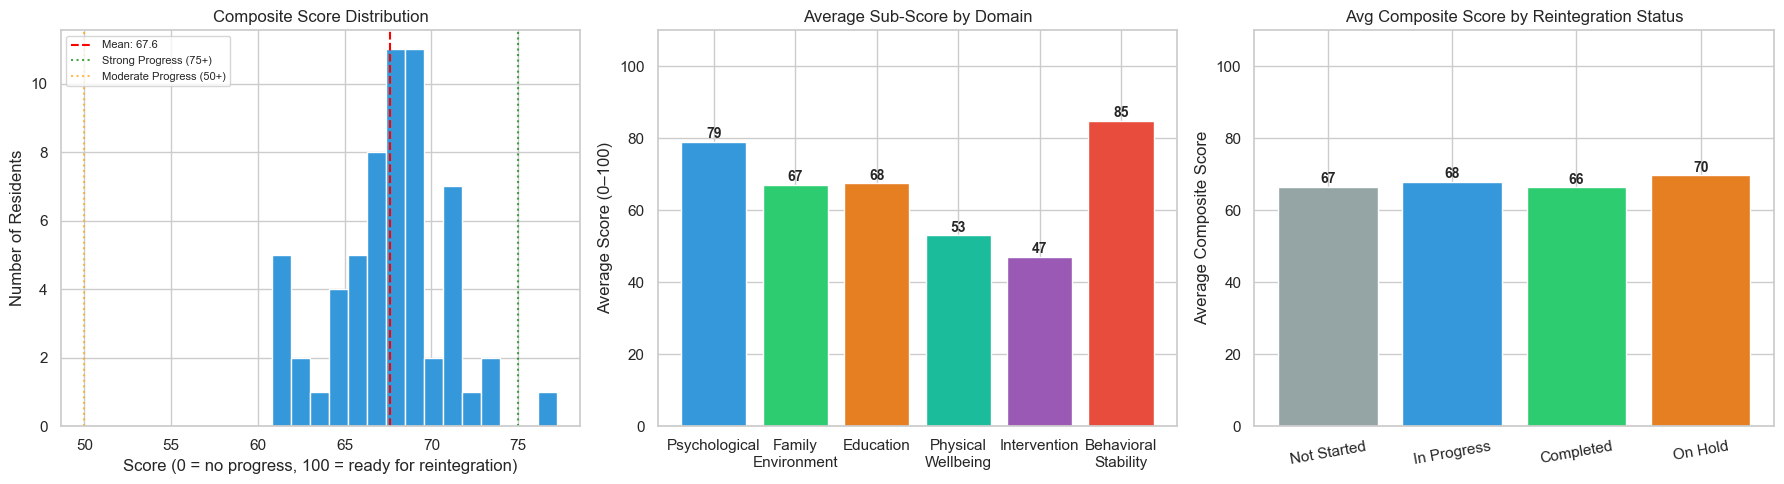

Top 5 residents by composite score:
case_control_no reintegration_status  composite_score     progress_band
          C6505          In Progress        77.221007   Strong Progress
          C3116              On Hold        73.652312 Moderate Progress
          C5189              On Hold        72.928333 Moderate Progress
          C8844          In Progress        71.942401 Moderate Progress
          C5401          Not Started        71.682948 Moderate Progress

Bottom 5 residents by composite score (need most attention):
case_control_no reintegration_status  composite_score     progress_band
          C2175            Completed        60.790742 Moderate Progress
          C3946            Completed        61.068946 Moderate Progress
          C5829            Completed        61.284907 Moderate Progress
          C3706          Not Started        61.317927 Moderate Progress
          C0043          In Progress        61.551950 Moderate Progress


In [ ]:
# =============================================================================
# PHASE 4, STEP 3: Visualize the scores
#
# These charts help staff understand at a glance how the resident population
# is distributed across the scoring spectrum, and which domains are strongest
# or weakest across the program.
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Chart 1: Distribution of composite scores ---
axes[0].hist(scores["composite_score"].dropna(), bins=15, color="#3498db", edgecolor="white")
axes[0].axvline(scores["composite_score"].mean(), color="red", linestyle="--",
                label=f"Mean: {scores['composite_score'].mean():.1f}")
axes[0].axvline(75, color="green", linestyle=":", alpha=0.7, label="Strong Progress (75+)")
axes[0].axvline(50, color="orange", linestyle=":", alpha=0.7, label="Moderate Progress (50+)")
axes[0].set_title("Composite Score Distribution", fontsize=12)
axes[0].set_xlabel("Score (0 = no progress, 100 = ready for reintegration)")
axes[0].set_ylabel("Number of Residents")
axes[0].legend(fontsize=8)

# --- Chart 2: Average sub-score per domain ---
domain_labels_short = ["Psychological", "Family\nEnvironment", "Education",
                       "Physical\nWellbeing", "Intervention", "Behavioral\nStability"]
domain_score_cols   = ["psych_score", "family_score", "education_score",
                       "health_score", "intervention_score", "behavioral_score"]
domain_means = [scores[col].mean() for col in domain_score_cols]
domain_colors_list  = ["#3498db", "#2ecc71", "#e67e22", "#1abc9c", "#9b59b6", "#e74c3c"]

bars = axes[1].bar(domain_labels_short, domain_means, color=domain_colors_list)
axes[1].set_title("Average Sub-Score by Domain", fontsize=12)
axes[1].set_ylabel("Average Score (0–100)")
axes[1].set_ylim(0, 110)
for bar, mean in zip(bars, domain_means):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 f"{mean:.0f}", ha="center", fontsize=10, fontweight="bold")

# --- Chart 3: Composite score by reintegration status ---
status_order_plot = ["Not Started", "In Progress", "Completed", "On Hold"]
status_scores = []
for status in status_order_plot:
    vals = scores[scores["reintegration_status"] == status]["composite_score"].dropna()
    status_scores.append(vals.mean() if len(vals) > 0 else 0)

axes[2].bar(status_order_plot, status_scores,
            color=["#95a5a6", "#3498db", "#2ecc71", "#e67e22"])
axes[2].set_title("Avg Composite Score by Reintegration Status", fontsize=12)
axes[2].set_ylabel("Average Composite Score")
axes[2].tick_params(axis="x", rotation=10)
axes[2].set_ylim(0, 110)
for i, v in enumerate(status_scores):
    axes[2].text(i, v + 1, f"{v:.0f}", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

# Print top 5 and bottom 5 residents
print("Top 5 residents by composite score:")
top5 = scores.nlargest(5, "composite_score")[["case_control_no", "reintegration_status", "composite_score", "progress_band"]]
print(top5.to_string(index=False))
print()
print("Bottom 5 residents by composite score (need most attention):")
bot5 = scores.nsmallest(5, "composite_score")[["case_control_no", "reintegration_status", "composite_score", "progress_band"]]
print(bot5.to_string(index=False))

# Phase 5: Trend Analysis

A single snapshot score tells us where a resident stands *today*. But to truly
track reintegration progress, we need to know **how the score is changing over time**.

In this phase, we compute the composite score for each resident at each calendar
month where records exist, creating a time series. We then:

1. Compute the month-over-month score change (delta)
2. Assign a trend status to each resident's *most recent* trajectory:
   - **Progressing**: Score increased this month
   - **Stable**: Score is roughly flat (change within ±2 points)
   - **Stalling**: Score has been flat or declining for 2+ consecutive months
   - **Regressing**: Score dropped by 5+ points in one month

The education and health records (which are already organized monthly) serve as
the backbone for the monthly timeline. Counseling and visitation data are
accumulated cumulatively up to each scoring date.

In [ ]:
# =============================================================================
# PHASE 5, STEP 1: Compute monthly composite scores for each resident
#
# WHAT: For each resident, for each month where we have education or health
# records, we compute the composite score using data up to that month.
# This creates a timeline of scores — one row per resident per month.
#
# WHY: A timeline lets us see if a resident is improving month by month,
# staying flat, or declining — which is information a single snapshot cannot
# show us.
# =============================================================================

# Build a list of all scoring months from education and health records
# (These are the most consistently monthly records in the dataset)
df_education["score_month"] = df_education["record_date"].dt.to_period("M")
df_health["score_month"]    = df_health["record_date"].dt.to_period("M")

# Residents with 'Completed' reintegration status are no longer active in the system.
# Trend tracking is only meaningful for residents who are still in the process.
active_ids = set(
    df_residents.loc[
        df_residents["reintegration_status"] != "Completed",
        "resident_id"
    ]
)
excluded_count = df_residents["reintegration_status"].eq("Completed").sum()

# All unique resident-month combinations from education (our primary timeline anchor)
monthly_grid = df_education[["resident_id", "score_month"]].drop_duplicates().copy()

# Also include months from health records in case a resident has health but no education
health_grid = df_health[["resident_id", "score_month"]].drop_duplicates()
monthly_grid = pd.concat([monthly_grid, health_grid]).drop_duplicates()

# Drop completed residents — they are no longer tracked for trend
monthly_grid = monthly_grid[monthly_grid["resident_id"].isin(active_ids)]
monthly_grid = monthly_grid.sort_values(["resident_id", "score_month"]).reset_index(drop=True)

print(f"Trend tracking: {excluded_count} resident(s) excluded (reintegration Completed)")
print(f"Monthly scoring grid: {len(monthly_grid)} resident-month combinations")
print(f"  Covering: {monthly_grid['score_month'].min()} to {monthly_grid['score_month'].max()}")
print(f"  Across {monthly_grid['resident_id'].nunique()} active residents")
print()

# Function: compute composite score for one resident at one scoring month
def score_for_month(resident_id, score_month):
    """Return a dict of sub-scores and composite for a given resident and month."""
    period_end = score_month.to_timestamp(how="end")  # last day of the scoring month

    # --- EDUCATION: only this month's records ---
    edu_m = df_education[
        (df_education["resident_id"] == resident_id) &
        (df_education["score_month"]  == score_month)
    ]
    if len(edu_m) > 0:
        edu_score = (
            edu_m["attendance_rate"].mean() * 100 * 0.35 +
            edu_m["progress_percent"].mean()       * 0.35 +
            edu_m["completion_status"].map({"NotStarted": 0.0, "InProgress": 0.5, "Completed": 1.0}).mean() * 100 * 0.30
        )
    else:
        edu_score = np.nan

    # --- HEALTH: only this month's records ---
    health_m = df_health[
        (df_health["resident_id"] == resident_id) &
        (df_health["score_month"]  == score_month)
    ]
    if len(health_m) > 0:
        h = health_m.iloc[0]
        health_score = (
            (h["general_health_score"] - 1) / 4 +
            (h["nutrition_score"]      - 1) / 4 +
            (h["sleep_quality_score"]          - 1) / 4 +
            (h["energy_level_score"]         - 1) / 4
        ) / 4 * 100
    else:
        health_score = np.nan

    # --- PSYCHOLOGICAL: cumulative up to this month ---
    psych_m = df_process[
        (df_process["resident_id"] == resident_id) &
        (df_process["session_date"] <= period_end)
    ]
    if len(psych_m) > 0:
        emo_delta_norm = ((psych_m["emotional_delta"].mean() + 5) / 10 * 100).clip(0, 100)
        psych_score = (
            psych_m["progress_noted"].mean()    * 100 * 0.40 +
            (1 - psych_m["concerns_flagged"].mean()) * 100 * 0.30 +
            emo_delta_norm                             * 0.30
        )
    else:
        psych_score = np.nan

    # --- FAMILY: cumulative up to this month ---
    visit_m = df_visitations[
        (df_visitations["resident_id"] == resident_id) &
        (df_visitations["visit_date"]   <= period_end)
    ]
    if len(visit_m) > 0:
        family_score = (
            visit_m["cooperation_num"].mean()   * 100 * 0.40 +
            visit_m["visit_outcome_num"].mean() * 100 * 0.40 +
            (1 - visit_m["safety_concerns_noted"].mean()) * 100 * 0.20
        )
    else:
        family_score = np.nan

    # --- INTERVENTION: cumulative up to this month ---
    plans_m = df_interventions[
        (df_interventions["resident_id"] == resident_id) &
        (df_interventions["updated_at"]   <= period_end)
    ]
    if len(plans_m) > 0:
        reint_plans = plans_m[plans_m["plan_category"] == "Reintegration"]
        if len(reint_plans) > 0:
            intervention_score = reint_plans["plan_status_num"].mean() * 100
        else:
            intervention_score = plans_m["plan_status_num"].mean() * 100
    else:
        intervention_score = np.nan

    # --- BEHAVIORAL: all incidents on record up to this month ---
    inc_m = df_incidents[
        (df_incidents["resident_id"]   == resident_id) &
        (df_incidents["incident_date"] <= period_end)
    ]
    n_incidents = len(inc_m)
    n_serious   = ((inc_m["incident_type"] == "SelfHarm") | (inc_m["incident_type"] == "RunawayAttempt")).sum()
    behavioral_score = (100 - min(n_incidents * 4, 40) - min(n_serious * 12, 36))
    behavioral_score = max(behavioral_score, 0)

    # --- Composite: weighted average of available domains ---
    domain_vals = {
        "psychological":      psych_score,
        "family_environment": family_score,
        "education":          edu_score,
        "physical_wellbeing": health_score,
        "intervention":       intervention_score,
        "behavioral":         behavioral_score,
    }
    total_weight = sum(DOMAIN_WEIGHTS[d] for d, v in domain_vals.items() if pd.notna(v))
    composite = (
        sum(v * DOMAIN_WEIGHTS[d] for d, v in domain_vals.items() if pd.notna(v)) / total_weight
        if total_weight > 0 else np.nan
    )

    return {
        "resident_id":         resident_id,
        "score_month":         score_month,
        "psych_score":         psych_score,
        "family_score":        family_score,
        "education_score":     edu_score,
        "health_score":        health_score,
        "intervention_score":  intervention_score,
        "behavioral_score":    behavioral_score,
        "composite_score":     round(composite, 2) if pd.notna(composite) else np.nan,
    }

# Apply function to all resident-month combinations
print(f"Computing monthly scores for {len(monthly_grid)} resident-month combinations...")
monthly_results = monthly_grid.apply(
    lambda row: score_for_month(row["resident_id"], row["score_month"]), axis=1
)
df_monthly = pd.DataFrame(monthly_results.tolist())
df_monthly["score_month_str"] = df_monthly["score_month"].astype(str)

print(f"Done. Monthly scores table: {df_monthly.shape[0]} rows x {df_monthly.shape[1]} columns")
print()
print("Sample monthly scores (first 5 rows):")
print(df_monthly[["resident_id", "score_month_str", "composite_score"]].head().to_string(index=False))

Trend tracking: 19 resident(s) excluded (reintegration Completed)
Monthly scoring grid: 364 resident-month combinations
  Covering: 2023-01 to 2026-02
  Across 41 active residents

Computing monthly scores for 364 resident-month combinations...
Done. Monthly scores table: 364 rows x 10 columns

Sample monthly scores (first 5 rows):
 resident_id score_month_str  composite_score
           1         2023-10            55.20
           1         2023-11            64.78
           1         2023-12            65.22
           1         2024-01            62.88
           1         2024-02            62.32


In [ ]:
# =============================================================================
# PHASE 5, STEP 2: Compute month-over-month deltas and assign trend flags
#
# WHAT: For each resident, compare their score this month to last month.
# Then determine whether they are Progressing, Stable, Stalling, or Regressing.
# =============================================================================

# Sort by resident and month so we can compare consecutive rows
df_monthly = df_monthly.sort_values(["resident_id", "score_month"]).reset_index(drop=True)

# Compute month-over-month delta for each resident
# The shift(1) looks at the PREVIOUS row for the same resident
df_monthly["prev_score"] = df_monthly.groupby("resident_id")["composite_score"].shift(1)
df_monthly["delta"]      = df_monthly["composite_score"] - df_monthly["prev_score"]

# Flag whether this month's delta was "flat" (within ±2 points)
df_monthly["is_flat"] = df_monthly["delta"].abs() <= 2

# Count consecutive flat months (for Stalling detection)
def _count_consec_flat(flat_series):
    """Return a Series counting consecutive True runs (resets to 0 on False)."""
    result, count = [], 0
    for val in flat_series:
        count = count + 1 if val else 0
        result.append(count)
    return pd.Series(result, index=flat_series.index)

df_monthly["consecutive_flat"] = (
    df_monthly.groupby("resident_id")["is_flat"].transform(_count_consec_flat)
)

# Assign trend status for each row
def assign_trend(row):
    if pd.isna(row["delta"]):
        return "First Month"             # No prior month to compare to
    if row["delta"] <= REGRESS_DELTA:
        return "Regressing"              # Score dropped sharply — urgent attention
    if row["consecutive_flat"] >= STALLING_MONTHS:
        return "Stalling"                # Score flat for too long — review care plan
    if row["delta"] > 2:
        return "Progressing"             # Score improved — current plan is working
    return "Stable"                      # Small fluctuation — maintaining

df_monthly["trend_status"] = df_monthly.apply(assign_trend, axis=1)

print("Trend flags assigned across all monthly scores.")
print()
print("Distribution of trend statuses (all monthly rows):")
trend_counts = df_monthly["trend_status"].value_counts()
for status, count in trend_counts.items():
    pct = count / len(df_monthly) * 100
    print(f"  {status:<15}: {count:>5} rows ({pct:.1f}%)")

# Extract the MOST RECENT trend status per resident
current_trend = (
    df_monthly
    .sort_values(["resident_id", "score_month"])
    .groupby("resident_id")
    .last()[["score_month", "composite_score", "delta", "trend_status"]]
    .reset_index()
    .rename(columns={
        "score_month":     "latest_score_month",
        "composite_score": "latest_composite_score",
        "delta":           "latest_delta",
        "trend_status":    "current_trend",
    })
)

print()
print("Current trend status per resident (most recent month):")
current_trend_counts = current_trend["current_trend"].value_counts()
for status, count in current_trend_counts.items():
    pct = count / len(current_trend) * 100
    print(f"  {status:<15}: {count:>3} residents ({pct:.0f}%)")

Trend flags assigned across all monthly scores.

Distribution of trend statuses (all monthly rows):
  Progressing    :   123 rows (33.8%)
  Stable         :   102 rows (28.0%)
  Stalling       :    87 rows (23.9%)
  First Month    :    41 rows (11.3%)
  Regressing     :    11 rows (3.0%)

Current trend status per resident (most recent month):
  Stable         :  19 residents (46%)
  Progressing    :   8 residents (20%)
  Stalling       :   8 residents (20%)
  Regressing     :   6 residents (15%)


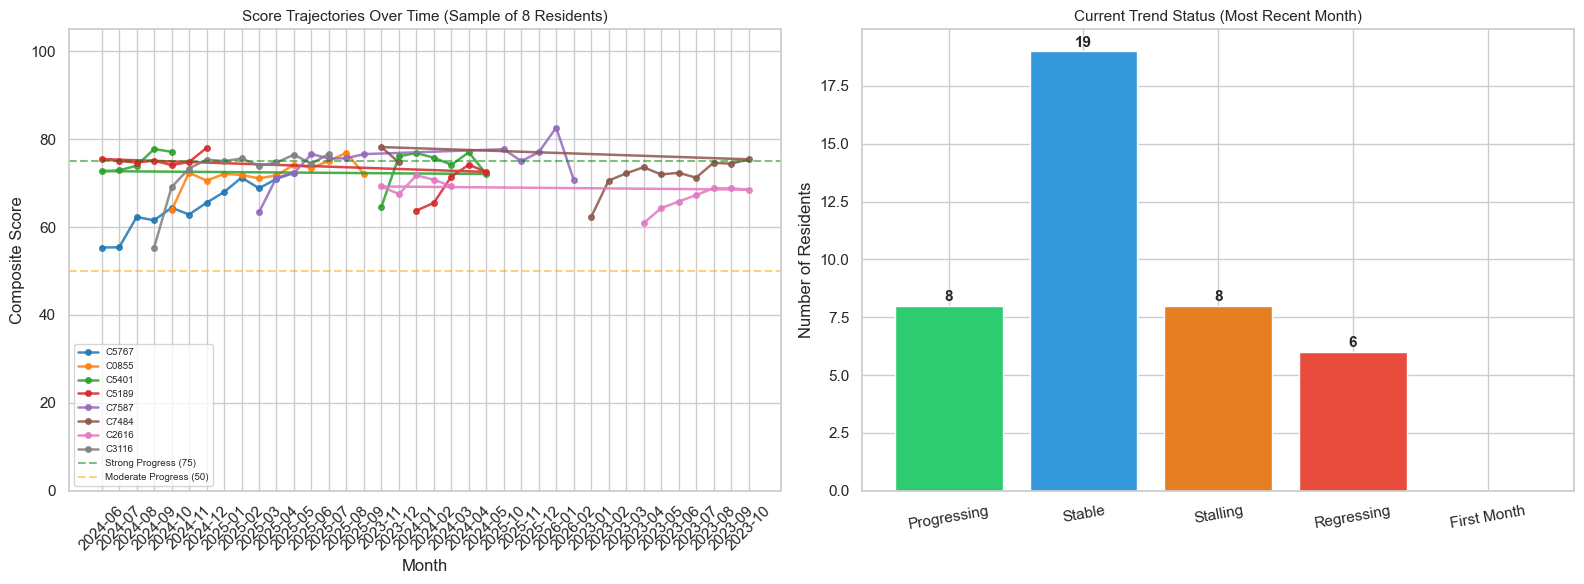

In [ ]:
# =============================================================================
# PHASE 5, STEP 3: Visualize score trends
#
# WHAT: Line chart showing score trajectories over time for a sample of
# residents, and a summary of current trend flags across all residents.
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Chart 1: Score trajectories for a sample of residents ---
# Select up to 8 residents with the most monthly data points (richest trend lines)
top_residents = (
    df_monthly.groupby("resident_id").size()
    .nlargest(8)
    .index.tolist()
)
sample_monthly = df_monthly[df_monthly["resident_id"].isin(top_residents)].copy()
sample_monthly["month_label"] = sample_monthly["score_month"].astype(str)

palette = sns.color_palette("tab10", n_colors=len(top_residents))
for i, rid in enumerate(top_residents):
    subset = sample_monthly[sample_monthly["resident_id"] == rid].sort_values("score_month")
    # Look up the case control number for a more readable label
    case_no = df_residents.loc[df_residents["resident_id"] == rid, "case_control_no"].values
    label   = case_no[0] if len(case_no) > 0 else f"Resident {rid}"
    axes[0].plot(
        subset["month_label"],
        subset["composite_score"],
        marker="o", linewidth=1.8, markersize=4,
        color=palette[i], label=label, alpha=0.85
    )

axes[0].axhline(75, color="green",  linestyle="--", alpha=0.5, label="Strong Progress (75)")
axes[0].axhline(50, color="orange", linestyle="--", alpha=0.5, label="Moderate Progress (50)")
axes[0].set_title("Score Trajectories Over Time (Sample of 8 Residents)", fontsize=11)
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Composite Score")
axes[0].set_ylim(0, 105)
axes[0].legend(fontsize=7, loc="lower left")
axes[0].tick_params(axis="x", rotation=45)

# --- Chart 2: Current trend status distribution ---
trend_order  = ["Progressing", "Stable", "Stalling", "Regressing", "First Month"]
trend_colors = ["#2ecc71",     "#3498db",  "#e67e22",   "#e74c3c",  "#95a5a6"]
trend_vals   = [current_trend_counts.get(t, 0) for t in trend_order]

axes[1].bar(trend_order, trend_vals, color=trend_colors)
axes[1].set_title("Current Trend Status (Most Recent Month)", fontsize=11)
axes[1].set_ylabel("Number of Residents")
for i, v in enumerate(trend_vals):
    if v > 0:
        axes[1].text(i, v + 0.2, str(v), ha="center", fontsize=11, fontweight="bold")
axes[1].tick_params(axis="x", rotation=10)

plt.tight_layout()
plt.show()

# Phase 6: Output and Deployment

The final phase produces everything staff and the web application need:

1. **Ranked summary table** — all residents sorted by composite score, showing
   all sub-scores, current trend, and reintegration status
2. **Attention flags table** — residents who are Stalling or Regressing, sorted
   by urgency so social workers know exactly who to prioritize
3. **CSV exports** — both tables saved to `models/` for the web application
4. **`score_resident()` function** — a reusable function that computes the
   composite score for a specific resident on demand
5. **Saved config** — the scoring weights and thresholds saved to a file,
   so future pipeline runs use exactly the same settings

In [ ]:
# =============================================================================
# PHASE 6, STEP 1: Build the ranked summary table
#
# WHAT: Combine the current composite scores (Phase 4) with the current trend
# status (Phase 5) into one unified table. Sort from highest score to lowest.
# =============================================================================

# Merge composite scores with current trend status
summary = scores.merge(current_trend[["resident_id", "latest_composite_score",
                                      "latest_delta", "current_trend"]],
                       on="resident_id", how="left")

# Round all score columns for display
score_display_cols = ["composite_score", "psych_score", "family_score",
                      "education_score", "health_score", "intervention_score", "behavioral_score"]
for col in score_display_cols:
    summary[col] = summary[col].round(1)

# Sort by composite score descending (highest progress at top)
summary = summary.sort_values("composite_score", ascending=False).reset_index(drop=True)
summary["rank"] = range(1, len(summary) + 1)

# Select and rename columns for display
display_cols = [
    "rank", "case_control_no", "reintegration_status", "reintegration_type",
    "composite_score", "progress_band", "current_trend",
    "psych_score", "family_score", "education_score",
    "health_score", "intervention_score", "behavioral_score",
]
summary_display = summary[display_cols].copy()

print("Ranked Summary Table (Top 15 Residents):")
print(summary_display.head(15).to_string(index=False))
print()
print(f"Full table: {len(summary_display)} residents")

Ranked Summary Table (Top 15 Residents):
 rank case_control_no reintegration_status       reintegration_type  composite_score     progress_band current_trend  psych_score  family_score  education_score  health_score  intervention_score  behavioral_score
    1           C6505          In Progress       Independent Living             77.2   Strong Progress   Progressing         81.3          73.5             73.0          52.8               100.0             100.0
    2           C3116              On Hold                     None             73.7 Moderate Progress   Progressing         81.3          77.8             74.8          50.1                50.0              88.0
    3           C5189              On Hold                     None             72.9 Moderate Progress   Progressing         80.9          86.0             63.4          50.2                60.0              80.0
    4           C8844          In Progress              Foster Care             71.9 Moderate Progress     

In [ ]:
# =============================================================================
# PHASE 6, STEP 2: Build the attention flags table
#
# WHAT: Extract residents who are Stalling or Regressing and need immediate
# attention from social workers. Sorted by urgency:
#   1. Regressing residents first (score dropping — most urgent)
#   2. Stalling residents second (score stuck — needs care plan review)
# =============================================================================

# Flag residents who need attention
flags = summary[
    summary["current_trend"].isin(["Regressing", "Stalling"])
].copy()

# Sort: Regressing first, then Stalling, then by lowest score
trend_priority = {"Regressing": 0, "Stalling": 1}
flags["trend_priority"] = flags["current_trend"].map(trend_priority)
flags = flags.sort_values(["trend_priority", "composite_score"]).reset_index(drop=True)
flags = flags.drop(columns=["trend_priority"])

flag_display_cols = [
    "case_control_no", "reintegration_status", "reintegration_type",
    "composite_score", "current_trend", "latest_delta",
    "psych_score", "family_score", "education_score",
    "health_score", "intervention_score", "behavioral_score",
]
flags_display = flags[[c for c in flag_display_cols if c in flags.columns]].copy()

print(f"ATTENTION FLAGS — {len(flags_display)} residents need social worker review:")
print()
if len(flags_display) > 0:
    print(flags_display.to_string(index=False))
else:
    print("  No residents currently flagged as Stalling or Regressing.")

print()
print(f"Summary: {(summary['current_trend'] == 'Regressing').sum()} Regressing, "
      f"{(summary['current_trend'] == 'Stalling').sum()} Stalling, "
      f"{(summary['current_trend'] == 'Progressing').sum()} Progressing")

ATTENTION FLAGS — 14 residents need social worker review:

case_control_no reintegration_status       reintegration_type  composite_score current_trend  latest_delta  psych_score  family_score  education_score  health_score  intervention_score  behavioral_score
          C4279              On Hold     Family Reunification             63.3    Regressing         -5.88         72.9          63.1             73.5          50.9                20.0             100.0
          C7521          In Progress     Family Reunification             64.6    Regressing         -9.77         81.5          63.1             76.1          54.8                10.0              80.0
          C3752          Not Started      Adoption (Domestic)             65.6    Regressing         -9.66         82.0          61.8             68.0          52.1                30.0              64.0
          C7286          In Progress     Family Reunification             66.0    Regressing         -7.08         80.8          

In [ ]:
# =============================================================================
# PHASE 6, STEP 3: Export results to CSV
#
# WHAT: Save two output files to the models/ folder:
#   1. reintegration_scores.csv — the full ranked summary table
#   2. reintegration_flags.csv  — residents who need attention
# WHY: The web application reads these files to display the dashboard.
# Re-run this notebook monthly to refresh both files with the latest data.
# =============================================================================

# Save the full summary table
summary_display.to_csv(SCORE_SAVE_PATH, index=False)
print(f"Saved: {SCORE_SAVE_PATH}")
print(f"  {len(summary_display)} rows, {len(summary_display.columns)} columns")
print()

# Save the attention flags table
if len(flags_display) > 0:
    flags_display.to_csv(FLAG_SAVE_PATH, index=False)
    print(f"Saved: {FLAG_SAVE_PATH}")
    print(f"  {len(flags_display)} residents flagged for attention")
else:
    # Write an empty file with headers so the web application still finds the file
    flags_display.to_csv(FLAG_SAVE_PATH, index=False)
    print(f"Saved: {FLAG_SAVE_PATH} (empty — no residents currently flagged)")

# Also save the full monthly time-series for trending dashboards
monthly_save_path = "models/reintegration_monthly_trend.csv"
df_monthly.to_csv(monthly_save_path, index=False)
print(f"Saved: {monthly_save_path}")
print(f"  {len(df_monthly)} monthly snapshots across all residents")

Saved: models/reintegration_scores.csv
  60 rows, 13 columns

Saved: models/reintegration_flags.csv
  14 residents flagged for attention
Saved: models/reintegration_monthly_trend.csv
  364 monthly snapshots across all residents


In [ ]:
# =============================================================================
# PHASE 6, STEP 4: Reusable score_resident() function
#
# WHAT: A ready-to-use function that computes the full reintegration progress
# score for any single resident, given their data from all seven tables.
# WHY: The web application can call this function on demand to get an up-to-date
# score for a specific resident without re-running the whole pipeline.
# =============================================================================

def score_resident(
    resident_id,
    df_residents_new,
    df_process_new,
    df_visitations_new,
    df_incidents_new,
    df_education_new,
    df_health_new,
    df_interventions_new,
    domain_weights=None,
):
    """
    Compute the Reintegration Progress Score for a single resident.

    Parameters
    ----------
    resident_id : int
        The resident_id to score.
    df_*_new : pd.DataFrame
        DataFrames for each of the seven source tables. These should be the
        full tables (not pre-filtered) — the function filters internally.
    domain_weights : dict, optional
        Domain weight dictionary. Defaults to the DOMAIN_WEIGHTS config value.

    Returns
    -------
    dict with keys:
        resident_id, composite_score, progress_band,
        psych_score, family_score, education_score,
        health_score, intervention_score, behavioral_score,
        domains_available
    """
    if domain_weights is None:
        domain_weights = DOMAIN_WEIGHTS

    # --- Filter to this resident ---
    r_proc  = df_process_new[df_process_new["resident_id"] == resident_id].copy()
    r_visit = df_visitations_new[df_visitations_new["resident_id"] == resident_id].copy()
    r_edu   = df_education_new[df_education_new["resident_id"] == resident_id].copy()
    r_hlth  = df_health_new[df_health_new["resident_id"] == resident_id].copy()
    r_plans = df_interventions_new[df_interventions_new["resident_id"] == resident_id].copy()
    r_inc   = df_incidents_new[df_incidents_new["resident_id"] == resident_id].copy()

    # --- Apply encodings ---
    r_proc["emotional_start_num"] = r_proc["emotional_state_observed"].map(EMOTIONAL_MAP)
    r_proc["emotional_end_num"]   = r_proc["emotional_state_end"].map(EMOTIONAL_MAP)
    r_proc["emotional_delta"]     = r_proc["emotional_end_num"] - r_proc["emotional_start_num"]
    r_visit["cooperation_num"]    = r_visit["family_cooperation_level"].map(COOPERATION_MAP)
    r_visit["visit_outcome_num"]  = r_visit["visit_outcome"].map(VISIT_OUTCOME_MAP)
    r_plans["plan_status_num"]    = r_plans["status"].map(PLAN_STATUS_MAP)

    # --- Compute sub-scores ---
    result = {"resident_id": resident_id}
    domains_available = []

    # Psychological
    if len(r_proc) > 0:
        emo_norm = ((r_proc["emotional_delta"].mean() + 5) / 10 * 100)
        result["psych_score"] = round(
            r_proc["progress_noted"].mean()         * 100 * 0.40 +
            (1 - r_proc["concerns_flagged"].mean()) * 100 * 0.30 +
            max(0, min(100, emo_norm))                     * 0.30, 1)
        domains_available.append("psychological")
    else:
        result["psych_score"] = None

    # Family Environment
    if len(r_visit) > 0:
        result["family_score"] = round(
            r_visit["cooperation_num"].mean()   * 100 * 0.40 +
            r_visit["visit_outcome_num"].mean() * 100 * 0.40 +
            (1 - r_visit["safety_concerns_noted"].mean()) * 100 * 0.20, 1)
        domains_available.append("family_environment")
    else:
        result["family_score"] = None

    # Education
    if len(r_edu) > 0:
        result["education_score"] = round(
            r_edu["attendance_rate"].mean()              * 100 * 0.35 +
            r_edu["progress_percent"].mean()                    * 0.35 +
            r_edu["completion_status"].map({"NotStarted": 0.0, "InProgress": 0.5, "Completed": 1.0}).mean() * 100 * 0.30, 1)
        domains_available.append("education")
    else:
        result["education_score"] = None

    # Physical Wellbeing
    if len(r_hlth) > 0:
        result["health_score"] = round(
            ((r_hlth["general_health_score"].mean() - 1) / 4 +
             (r_hlth["nutrition_score"].mean()       - 1) / 4 +
             (r_hlth["sleep_quality_score"].mean()           - 1) / 4 +
             (r_hlth["energy_level_score"].mean()          - 1) / 4) / 4 * 100, 1)
        domains_available.append("physical_wellbeing")
    else:
        result["health_score"] = None

    # Intervention
    if len(r_plans) > 0:
        reint = r_plans[r_plans["plan_category"] == "Reintegration"]
        base  = reint if len(reint) > 0 else r_plans
        result["intervention_score"] = round(base["plan_status_num"].mean() * 100, 1)
        domains_available.append("intervention")
    else:
        result["intervention_score"] = None

    # Behavioral Stability (always defined)
    n_serious = ((r_inc["incident_type"] == "SelfHarm") | (r_inc["incident_type"] == "RunawayAttempt")).sum()
    result["behavioral_score"] = max(0, 100 - min(len(r_inc) * 4, 40) - min(n_serious * 12, 36))
    domains_available.append("behavioral")

    # Composite: weighted average of available domains
    score_key_map = {
        "psychological":      "psych_score",
        "family_environment": "family_score",
        "education":          "education_score",
        "physical_wellbeing": "health_score",
        "intervention":       "intervention_score",
        "behavioral":         "behavioral_score",
    }
    total_w  = sum(domain_weights[d] for d in domains_available)
    composite= sum(result[score_key_map[d]] * domain_weights[d]
                   for d in domains_available
                   if result[score_key_map[d]] is not None) / total_w if total_w > 0 else None

    if composite is not None:
        composite = round(min(max(composite, 0), 100), 1)

    result["composite_score"]   = composite
    result["progress_band"]     = score_to_band(composite)
    result["domains_available"] = domains_available

    return result


# --- Quick demo: score the first resident in the dataset ---
demo_id = df_residents["resident_id"].iloc[0]
demo_result = score_resident(
    resident_id         = demo_id,
    df_residents_new    = df_residents,
    df_process_new      = df_process,
    df_visitations_new  = df_visitations,
    df_incidents_new    = df_incidents,
    df_education_new    = df_education,
    df_health_new       = df_health,
    df_interventions_new= df_interventions,
)

print("Demo: score_resident() output for one resident")
print("-" * 50)
for key, val in demo_result.items():
    print(f"  {key:<22}: {val}")

Demo: score_resident() output for one resident
--------------------------------------------------
  resident_id           : 1
  psych_score           : 78.8
  family_score          : 66.7
  education_score       : 53.5
  health_score          : 52.7
  intervention_score    : 20.0
  behavioral_score      : 72
  composite_score       : 60.6
  progress_band         : Moderate Progress
  domains_available     : ['psychological', 'family_environment', 'education', 'physical_wellbeing', 'intervention', 'behavioral']


In [ ]:
# =============================================================================
# PHASE 6, STEP 5: Save the scoring configuration
#
# WHAT: Save the weights, thresholds, and encoding maps to a file.
# WHY: This ensures that every time the pipeline re-runs (monthly), it uses
# the exact same settings — making scores comparable across time.
# If you want to change the weights, update the Config cell (Cell 1) and
# re-run the notebook. The new config will be saved here automatically.
# =============================================================================

import joblib

score_config = {
    "domain_weights":        DOMAIN_WEIGHTS,
    "stalling_months":       STALLING_MONTHS,
    "regress_delta":         REGRESS_DELTA,
    "emotional_map":         EMOTIONAL_MAP,
    "cooperation_map":       COOPERATION_MAP,
    "visit_outcome_map":     VISIT_OUTCOME_MAP,
    "plan_status_map":       PLAN_STATUS_MAP,
    "risk_level_map":        RISK_LEVEL_MAP,
    "random_state":          RANDOM_STATE,
    "score_save_path":       SCORE_SAVE_PATH,
    "flag_save_path":        FLAG_SAVE_PATH,
    "pipeline_version":      "1.0.0",
    "description": (
        "Reintegration Progress Scoring Pipeline — Lighthouse Sanctuary. "
        "Composite 0-100 score from 6 domain sub-scores. "
        "Domain weights are adjustable in the Config cell."
    ),
}

joblib.dump(score_config, CONFIG_SAVE_PATH)

print("Scoring configuration saved.")
print()
print("Saved files summary:")
for path in [SCORE_SAVE_PATH, FLAG_SAVE_PATH, "models/reintegration_monthly_trend.csv", CONFIG_SAVE_PATH]:
    try:
        size_kb = os.path.getsize(path) / 1024
        print(f"  {path:<45}: {size_kb:.1f} KB")
    except FileNotFoundError:
        print(f"  {path:<45}: (not found)")

print()
print("Pipeline complete. To refresh scores with new data:")
print("  1. Update the CSV paths in Cell 1 (Config) if needed")
print("  2. Run all cells (Kernel > Restart & Run All)")
print("  3. Updated CSVs will be saved to models/")

Scoring configuration saved.

Saved files summary:
  models/reintegration_scores.csv              : 5.9 KB
  models/reintegration_flags.csv               : 1.6 KB
  models/reintegration_monthly_trend.csv       : 39.5 KB
  models/reintegration_score_config.joblib     : 1.1 KB

Pipeline complete. To refresh scores with new data:
  1. Update the CSV paths in Cell 1 (Config) if needed
  2. Run all cells (Kernel > Restart & Run All)
  3. Updated CSVs will be saved to models/
